# EP3 TLY1101 · Modelos de Machine Learning supervisado: regresión y clasificación

**Integrantes del equipo**

- Martin Higuera
- Gabriel Duran

**Asignatura:** Machine Learning · Sección 002D  
**Entrega:** `TLY_TE2_002D_MHiguera_GDuran`

---

## Resumen del trabajo

Este cuaderno resuelve dos problemas de aprendizaje supervisado:

| Caso | Tipo | Dataset | Variable objetivo | Algoritmos |
|---|---|---|---|---|
| 1 | Regresión | `car_data.csv` | `precio_venta` (precio de venta del auto usado) | SVR y KNN Regressor |
| 2 | Clasificación | `breast_cancer.csv` | `diagnosis` (1 = maligno, 0 = benigno) | Regresión Logística y Árbol de Decisión |

Al final se incluye una sección de **selección y análisis** con las tablas resumen, el mejor modelo de cada caso y su justificación.

## Declaración de uso de inteligencia artificial

Se utilizó **OpenCode** (asistente de IA basado en un modelo de lenguaje) como apoyo para:

- revisar y ordenar la estructura del cuaderno,
- redactar el código y las explicaciones del Caso 1 y de la sección de selección y análisis,
- detectar y corregir errores de interpretación y de redacción en el Caso 2.

Todo el código fue ejecutado por el equipo y los resultados e interpretaciones se contrastaron contra las salidas reales del cuaderno. Las fuentes consultadas se listan al final del documento.

## Importación de librerías

In [1]:
import os
import shutil
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Caso 1: regresión
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Caso 2: clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score)

# Factor de inflación de varianza (VIF): requiere la librería statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# Carpeta donde se guardan las copias de los datos originales
os.makedirs("copy", exist_ok=True)

# Caso 1 · Regresión: predicción del precio de venta de autos usados

## Contexto y objetivo

Una empresa de compraventa de vehículos usados necesita **estimar a qué precio se puede vender un auto** a partir de sus características (año, kilometraje, tipo de combustible, tipo de vendedor, transmisión y número de propietarios anteriores). Una buena estimación ayuda a fijar precios coherentes y a evitar comprar autos sobrevalorados.

El dataset `car_data.csv` contiene 301 autos usados. **El objetivo es construir y comparar dos modelos de regresión (SVR y KNN) que predigan el precio de venta**, evaluándolos con MSE, RMSE y R², y explorando sus hiperparámetros con `GridSearchCV`.

### Aclaración sobre la variable objetivo

El enunciado indica como objetivo la variable `precio_venta_actual`. Sin embargo, en el archivo **el encabezado trae 8 nombres, pero cada fila trae 9 valores**:

```
encabezado: nom_auto, anno, precio_venta_actual, kilometraje, tipo_combustible, tipo_vendedor, transmision, propietario
fila 1    : ritz,     2014, 3.35,                5.59,        27000,            Petrol,        Dealer,        Manual,      0
```

Es decir, `precio_venta_actual` en realidad agrupa **dos columnas de precio** y el encabezado quedó desalineado. Al comparar con el dataset original (CarDekho, disponible en Kaggle), las nueve columnas reales son:

| Columna | Descripción |
|---|---|
| `nom_auto` | Modelo del auto |
| `anno` | Año de fabricación |
| `precio_venta` | **Precio al que se vendió el auto usado** (variable objetivo) |
| `precio_actual` | Precio actual del mismo modelo nuevo (se asume en las mismas unidades que `precio_venta`; en el dataset original son lakhs de rupias indias) |
| `kilometraje` | Kilómetros recorridos |
| `tipo_combustible` | Petrol, Diesel o CNG |
| `tipo_vendedor` | Dealer (concesionario) o Individual |
| `transmision` | Manual o Automatic |
| `propietario` | Número de dueños anteriores |

Por lo tanto, **la variable objetivo será `precio_venta`** y `precio_actual` se usa como una predictora más: es información que se conoce al momento de tasar el auto (el precio del modelo nuevo equivalente).

## Carga de datos y corrección del encabezado

Primero se crea una copia del archivo original para no alterarlo. Luego se lee la copia entregando explícitamente los nueve nombres de columna y usando `header=0` para descartar la fila de encabezado antigua (que está desalineada).

In [2]:
# Copia del archivo original (el original no se modifica)
shutil.copy("data_sets/car_data.csv", "copy/car_data_copy.csv")

# Lectura de la copia: 9 nombres correctos + header=0 para reemplazar el encabezado desalineado
columnas_auto = ["nom_auto", "anno", "precio_venta", "precio_actual", "kilometraje",
                 "tipo_combustible", "tipo_vendedor", "transmision", "propietario"]

df_auto = pd.read_csv("copy/car_data_copy.csv", names=columnas_auto, header=0)

print(f"Registros: {df_auto.shape[0]} | Columnas: {df_auto.shape[1]}")
df_auto.head(10)

Registros: 301 | Columnas: 9


,nom_auto,anno,precio_venta,precio_actual,kilometraje,tipo_combustible,tipo_vendedor,transmision,propietario
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


Con la corrección, cada columna recibe el dato que le corresponde: `precio_venta` = 3.35 y `precio_actual` = 5.59 en la primera fila.

## Análisis exploratorio

Se revisan los tipos de datos, los valores nulos, los duplicados y las estadísticas descriptivas.

In [3]:
print("Tipos de datos:")
print(df_auto.dtypes)

print("\nValores nulos por columna:")
print(df_auto.isnull().sum())

print(f"\nRegistros duplicados: {df_auto.duplicated().sum()}")

Tipos de datos:
nom_auto                str
anno                  int64
precio_venta        float64
precio_actual       float64
kilometraje           int64
tipo_combustible        str
tipo_vendedor           str
transmision             str
propietario           int64
dtype: object

Valores nulos por columna:
nom_auto            0
anno                0
precio_venta        0
precio_actual       0
kilometraje         0
tipo_combustible    0
tipo_vendedor       0
transmision         0
propietario         0
dtype: int64

Registros duplicados: 2


In [4]:
df_auto.describe().T

,count,mean,std,min,25%,50%,75%,max
anno,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
precio_venta,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
precio_actual,301.0,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
kilometraje,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
propietario,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0


In [5]:
# Distribución de las variables categóricas
for columna in ["tipo_combustible", "tipo_vendedor", "transmision", "propietario"]:
    print(f"--- {columna} ---")
    print(df_auto[columna].value_counts().to_string(), "\n")

print(f"Modelos de auto distintos en nom_auto: {df_auto['nom_auto'].nunique()}")

--- tipo_combustible ---
tipo_combustible
Petrol    239
Diesel     60
CNG         2 

--- tipo_vendedor ---
tipo_vendedor
Dealer        195
Individual    106 

--- transmision ---
transmision
Manual       261
Automatic     40 

--- propietario ---
propietario
0    290
1     10
3      1 

Modelos de auto distintos en nom_auto: 98


**Observaciones:**

- No hay valores nulos y los tipos de dato son correctos (3 columnas numéricas de decimales/enteros, `propietario` entero y 4 columnas de texto).
- Hay 2 registros duplicados (0,66 % del total). Son una proporción mínima y podrían corresponder a dos publicaciones distintas con las mismas características, por lo que **se conservan** para trabajar con los 301 registros del dataset original.
- La mayoría de los autos usa bencina (`Petrol`, 239), se vende por un concesionario (`Dealer`, 195), tiene transmisión manual (261) y no ha tenido otros dueños (290). La categoría `CNG` tiene solo 2 registros.
- `nom_auto` tiene 98 valores distintos en solo 301 registros. Convertirla con One-Hot Encoding crearía casi 100 columnas con muy pocos ejemplos cada una, lo que favorece el sobreajuste. Además, el enunciado pide codificar solo `tipo_combustible`, `tipo_vendedor` y `transmision`. **Se elimina `nom_auto`** y el efecto de la marca y modelo queda recogido, en parte, por `precio_actual`.

In [6]:
df_reg = df_auto.drop(columns=["nom_auto"])
df_reg.head()

,anno,precio_venta,precio_actual,kilometraje,tipo_combustible,tipo_vendedor,transmision,propietario
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


### Valores atípicos

Se revisan los valores extremos de las variables numéricas con diagramas de caja.

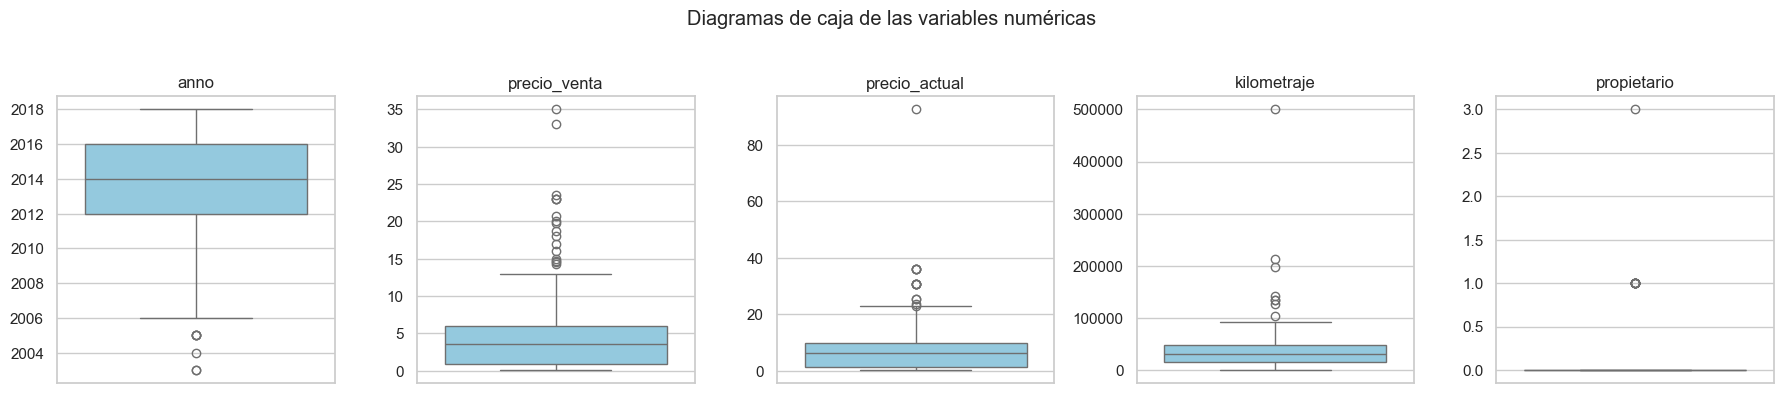

In [7]:
columnas_numericas = ["anno", "precio_venta", "precio_actual", "kilometraje", "propietario"]

fig, ejes = plt.subplots(1, 5, figsize=(18, 3.8))
for eje, columna in zip(ejes, columnas_numericas):
    sns.boxplot(y=df_reg[columna], ax=eje, color="skyblue")
    eje.set_title(columna)
    eje.set_ylabel("")
plt.suptitle("Diagramas de caja de las variables numéricas", y=1.03)
plt.tight_layout()
plt.show()

Hay autos con precios y kilometrajes muy superiores al resto (por ejemplo, un auto con 500.000 km y modelos nuevos de hasta 92,6 de precio). No parecen errores de digitación sino **autos reales de gama alta o con uso intensivo**, y eliminarlos dejaría al modelo sin ejemplos de ese segmento. Por eso **no se eliminan**; en cambio, se usan modelos y escalamiento adecuados y se reportan métricas robustas (validación cruzada) para no depender de una sola partición.

## Preprocesamiento de variables categóricas (One-Hot Encoding)

Se codifican `tipo_combustible`, `tipo_vendedor` y `transmision` con One-Hot Encoding. Se usa `drop_first=True` para eliminar una categoría de referencia por variable y así evitar columnas redundantes (la categoría eliminada queda implícita cuando todas las demás valen 0).

In [8]:
categoricas = ["tipo_combustible", "tipo_vendedor", "transmision"]

df_reg_ohe = pd.get_dummies(df_reg, columns=categoricas, drop_first=True, dtype=int)

print("Columnas después del One-Hot Encoding:")
print(list(df_reg_ohe.columns))
df_reg_ohe.head()

Columnas después del One-Hot Encoding:
['anno', 'precio_venta', 'precio_actual', 'kilometraje', 'propietario', 'tipo_combustible_Diesel', 'tipo_combustible_Petrol', 'tipo_vendedor_Individual', 'transmision_Manual']


,anno,precio_venta,precio_actual,kilometraje,propietario,tipo_combustible_Diesel,tipo_combustible_Petrol,tipo_vendedor_Individual,transmision_Manual
0,2014,3.35,5.59,27000,0,0,1,0,1
1,2013,4.75,9.54,43000,0,1,0,0,1
2,2017,7.25,9.85,6900,0,0,1,0,1
3,2011,2.85,4.15,5200,0,0,1,0,1
4,2014,4.60,6.87,42450,0,1,0,0,1


Las categorías de referencia (las eliminadas) son `CNG` para el combustible, `Dealer` para el tipo de vendedor y `Automatic` para la transmisión. Las columnas nuevas indican:

- `tipo_combustible_Diesel` / `tipo_combustible_Petrol`: 1 si el auto usa ese combustible.
- `tipo_vendedor_Individual`: 1 si lo vende una persona particular (0 = concesionario).
- `transmision_Manual`: 1 si la transmisión es manual (0 = automática).

## Correlación entre las variables y el precio de venta

Correlación de cada predictora con precio_venta:

precio_actual               0.879
tipo_combustible_Diesel     0.552
anno                        0.236
kilometraje                 0.029
propietario                -0.088
transmision_Manual         -0.367
tipo_combustible_Petrol    -0.541
tipo_vendedor_Individual   -0.551


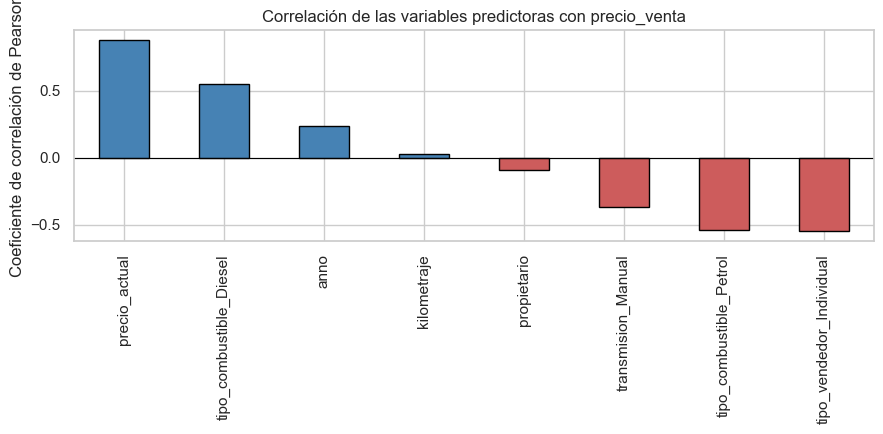

In [9]:
correlacion_precio = df_reg_ohe.corr()["precio_venta"].drop("precio_venta").sort_values(ascending=False)
print("Correlación de cada predictora con precio_venta:\n")
print(correlacion_precio.round(3).to_string())

plt.figure(figsize=(9, 4.5))
colores = ["steelblue" if v >= 0 else "indianred" for v in correlacion_precio.values]
correlacion_precio.plot(kind="bar", color=colores, edgecolor="black")
plt.axhline(0, color="black", lw=0.8)
plt.title("Correlación de las variables predictoras con precio_venta")
plt.ylabel("Coeficiente de correlación de Pearson")
plt.tight_layout()
plt.show()

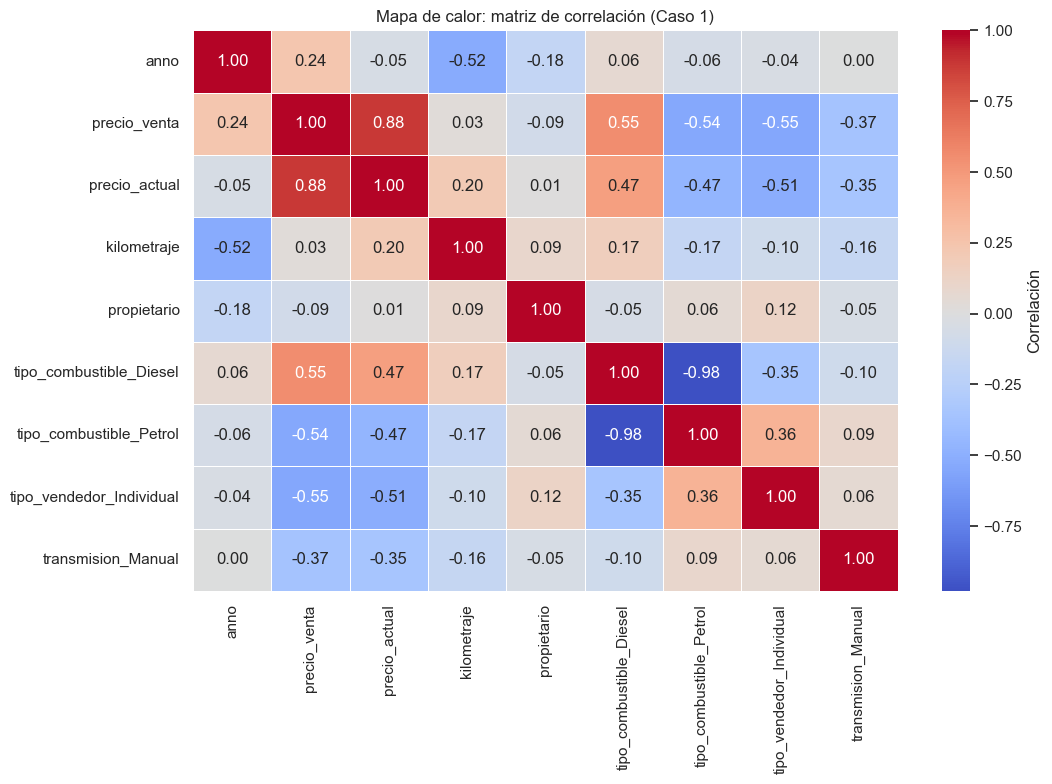

In [10]:
plt.figure(figsize=(11, 8))
sns.heatmap(df_reg_ohe.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0,
            linewidths=0.5, cbar_kws={"label": "Correlación"})
plt.title("Mapa de calor: matriz de correlación (Caso 1)")
plt.tight_layout()
plt.show()

**Interpretación:**

- `precio_actual` es, con diferencia, la variable más relacionada con el precio de venta (r ≈ 0,88): un auto cuyo modelo nuevo es caro también se vende más caro usado.
- `tipo_vendedor_Individual` (r ≈ −0,55), `tipo_combustible_Petrol` (r ≈ −0,54) y `transmision_Manual` (r ≈ −0,37) tienen correlación negativa: los autos vendidos por particulares, a bencina y manuales tienden a costar menos. `tipo_combustible_Diesel` (r ≈ 0,55) y `anno` (r ≈ 0,24, autos más nuevos) se asocian a precios más altos.
- `kilometraje` y `propietario` tienen una correlación lineal baja con el precio, aunque aportan información complementaria en combinación con las demás variables. Además, `kilometraje` y `anno` están correlacionados entre sí (r ≈ −0,52): los autos más nuevos tienen menos kilómetros.
- `tipo_combustible_Diesel` y `tipo_combustible_Petrol` tienen una correlación de −0,98 entre ellas, porque casi todos los autos son de uno de esos dos tipos (solo 2 son `CNG`). Es un efecto natural del One-Hot Encoding. Se conservan ambas porque SVR y KNN no estiman coeficientes, por lo que esa redundancia no les afecta de forma relevante.

## Separación en entrenamiento y prueba

Se separan las variables predictoras (`X`) y la variable objetivo (`y`) y se particiona el dataset en 80 % entrenamiento y 20 % prueba con `random_state=42`, como pide el enunciado.

In [11]:
X_reg = df_reg_ohe.drop(columns=["precio_venta"])
y_reg = df_reg_ohe["precio_venta"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train_r.shape[0]} registros | Prueba: {X_test_r.shape[0]} registros")
print(f"Predictoras utilizadas ({X_reg.shape[1]}): {list(X_reg.columns)}")

Entrenamiento: 240 registros | Prueba: 61 registros
Predictoras utilizadas (8): ['anno', 'precio_actual', 'kilometraje', 'propietario', 'tipo_combustible_Diesel', 'tipo_combustible_Petrol', 'tipo_vendedor_Individual', 'transmision_Manual']


## Escalamiento con StandardScaler

SVR y KNN dependen de **distancias** entre registros, por lo que una variable con valores grandes (como `kilometraje`, hasta 500.000) dominaría sobre otras (como `propietario`, de 0 a 3). Se estandarizan las variables (media 0 y desviación 1). El escalador se **ajusta solo con el conjunto de entrenamiento** y luego se aplica a ambos conjuntos, para no filtrar información de la prueba al entrenamiento (*data leakage*).

In [12]:
escalador_reg = StandardScaler()
X_train_r_sc = escalador_reg.fit_transform(X_train_r)   # fit solo con entrenamiento
X_test_r_sc = escalador_reg.transform(X_test_r)          # solo transform en prueba

pd.DataFrame(X_train_r_sc, columns=X_reg.columns).head(10).round(3)

,anno,precio_actual,kilometraje,propietario,tipo_combustible_Diesel,tipo_combustible_Petrol,tipo_vendedor_Individual,transmision_Manual
0,-1.970,-0.754,-0.276,3.528,-0.480,0.493,1.338,0.378
1,1.156,-0.731,-0.814,-0.186,-0.480,0.493,1.338,0.378
2,-1.970,-0.749,0.299,-0.186,-0.480,0.493,1.338,0.378
3,0.462,-0.079,-0.036,-0.186,-0.480,0.493,-0.747,0.378
4,0.809,-0.670,-0.690,-0.186,-0.480,0.493,1.338,0.378
5,0.114,3.170,0.084,-0.186,2.082,-2.026,-0.747,-2.646
6,0.462,2.574,0.060,-0.186,2.082,-2.026,-0.747,-2.646
7,0.462,0.068,-0.448,-0.186,-0.480,0.493,-0.747,0.378
8,-0.928,-0.749,0.898,-0.186,-0.480,0.493,1.338,0.378
9,-0.580,-0.171,0.334,-0.186,2.082,-2.026,-0.747,0.378


In [13]:
# Verificación: en entrenamiento la media es ~0 y la desviación ~1
print(pd.DataFrame(X_train_r_sc, columns=X_reg.columns).describe().loc[["mean", "std"]].round(3))

       anno  precio_actual  kilometraje  propietario  tipo_combustible_Diesel  tipo_combustible_Petrol  tipo_vendedor_Individual  transmision_Manual
mean -0.000         -0.000       -0.000       -0.000                   -0.000                   -0.000                    -0.000               0.000
std   1.002          1.002        1.002        1.002                    1.002                    1.002                     1.002               1.002


## Funciones auxiliares de evaluación

Para evaluar todos los modelos de regresión de la misma manera se define una función que calcula **MSE, RMSE, MAE y R²** sobre el conjunto de prueba, el R² en entrenamiento (para detectar sobreajuste) y el R² promedio de una validación cruzada de 5 particiones sobre el conjunto de entrenamiento (para no depender de una sola partición).

- **MSE:** promedio de los errores al cuadrado; penaliza más los errores grandes.
- **RMSE:** raíz del MSE; está en las mismas unidades que el precio.
- **MAE:** error absoluto promedio.
- **R²:** proporción de la variabilidad del precio que explica el modelo (1 = perfecto, 0 = no mejora a predecir siempre el promedio).

In [14]:
resultados_regresion = []   # aquí se acumulan las métricas de todos los modelos


def evaluar_regresion(nombre, modelo):
    """Calcula las métricas de un modelo ya entrenado y las guarda en resultados_regresion."""
    pred_test = modelo.predict(X_test_r_sc)
    pred_train = modelo.predict(X_train_r_sc)
    mse = mean_squared_error(y_test_r, pred_test)
    fila = {
        "Modelo": nombre,
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_test_r, pred_test),
        "R² prueba": r2_score(y_test_r, pred_test),
        "R² entrenamiento": r2_score(y_train_r, pred_train),
        "R² validación cruzada (5 folds)": cross_val_score(modelo, X_train_r_sc, y_train_r,
                                                          cv=5, scoring="r2").mean(),
    }
    resultados_regresion.append(fila)
    return fila, pred_test


def graficar_real_vs_predicho(predicciones, titulo):
    """Dispersión de valores reales vs predichos para cada modelo (diagonal = predicción perfecta)."""
    fig, ejes = plt.subplots(1, len(predicciones), figsize=(6.5 * len(predicciones), 5.5), sharex=True, sharey=True)
    ejes = np.atleast_1d(ejes)
    limite = max(y_test_r.max(), max(p.max() for p in predicciones.values())) * 1.05
    for eje, (nombre, pred) in zip(ejes, predicciones.items()):
        eje.scatter(y_test_r, pred, alpha=0.75, edgecolor="black", color="steelblue")
        eje.plot([0, limite], [0, limite], "r--", label="Predicción perfecta")
        eje.set_title(f"{nombre}\nR² = {r2_score(y_test_r, pred):.3f} | RMSE = {np.sqrt(mean_squared_error(y_test_r, pred)):.3f}")
        eje.set_xlabel("Precio de venta real")
        eje.set_ylabel("Precio de venta predicho")
        eje.legend()
    plt.suptitle(titulo, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## Modelo 1: SVR (Support Vector Regression)

El SVR busca una función que se mantenga dentro de un margen de tolerancia `epsilon` alrededor de los valores reales, penalizando con el parámetro `C` los puntos que quedan fuera. Con el kernel `rbf` puede capturar relaciones no lineales. Se entrena primero con la configuración pedida en el enunciado: `kernel='rbf'`, `C=1.0` y `epsilon=0.1`.

In [15]:
svr_base = SVR(kernel="rbf", C=1.0, epsilon=0.1)
svr_base.fit(X_train_r_sc, y_train_r)

fila_svr, pred_svr_base = evaluar_regresion("SVR base (rbf, C=1, ε=0.1)", svr_base)

print("=== SVR base ===")
print(f"MSE : {fila_svr['MSE']:.4f}")
print(f"RMSE: {fila_svr['RMSE']:.4f}")
print(f"MAE : {fila_svr['MAE']:.4f}")
print(f"R²  : {fila_svr['R² prueba']:.4f}  (entrenamiento: {fila_svr['R² entrenamiento']:.4f})")

=== SVR base ===
MSE : 5.1198
RMSE: 2.2627
MAE : 1.0108
R²  : 0.7777  (entrenamiento: 0.6565)


**Interpretación:** el SVR con los parámetros por defecto del enunciado explica cerca del 78 % de la variabilidad del precio en la prueba, con un error típico (RMSE) de unas 2,26 unidades de precio. Su R² en entrenamiento (≈ 0,66) es **incluso menor** que en prueba, señal de **subajuste (*underfitting*)**: con `C=1` el modelo está demasiado restringido para una variable objetivo que llega hasta 35 y con desviación estándar de 5, por lo que "achata" las predicciones de los autos caros. Esto se resolverá explorando hiperparámetros más adelante.

## Modelo 2: KNN Regressor (K vecinos más cercanos)

El KNN predice el precio de un auto como el **promedio del precio de sus `k` vecinos más parecidos** en el conjunto de entrenamiento (según la distancia entre variables escaladas). Se entrena con `n_neighbors=7`, como indica el enunciado.

In [16]:
knn_base = KNeighborsRegressor(n_neighbors=7)
knn_base.fit(X_train_r_sc, y_train_r)

fila_knn, pred_knn_base = evaluar_regresion("KNN base (k=7)", knn_base)

print("=== KNN base (k=7) ===")
print(f"MSE : {fila_knn['MSE']:.4f}")
print(f"RMSE: {fila_knn['RMSE']:.4f}")
print(f"MAE : {fila_knn['MAE']:.4f}")
print(f"R²  : {fila_knn['R² prueba']:.4f}  (entrenamiento: {fila_knn['R² entrenamiento']:.4f})")

=== KNN base (k=7) ===
MSE : 1.6512
RMSE: 1.2850
MAE : 0.7790
R²  : 0.9283  (entrenamiento: 0.8906)


**Interpretación:** el KNN con `k=7` explica cerca del 93 % de la variabilidad del precio en la prueba, con un RMSE de unas 1,29 unidades, es decir, un error considerablemente menor que el del SVR base. El R² de entrenamiento (≈ 0,89) es algo mayor que el de prueba, una brecha pequeña y normal: no hay sobreajuste importante.

## Comparación de los modelos base: valores reales vs. predichos

In [17]:
tabla_base = pd.DataFrame(resultados_regresion).set_index("Modelo")
tabla_base.round(4)

,MSE,RMSE,MAE,R² prueba,R² entrenamiento,R² validación cruzada (5 folds)
Modelo,,,,,,
"SVR base (rbf, C=1, ε=0.1)",5.1198,2.2627,1.0108,0.7777,0.6565,0.6011
KNN base (k=7),1.6512,1.2850,0.7790,0.9283,0.8906,0.8305


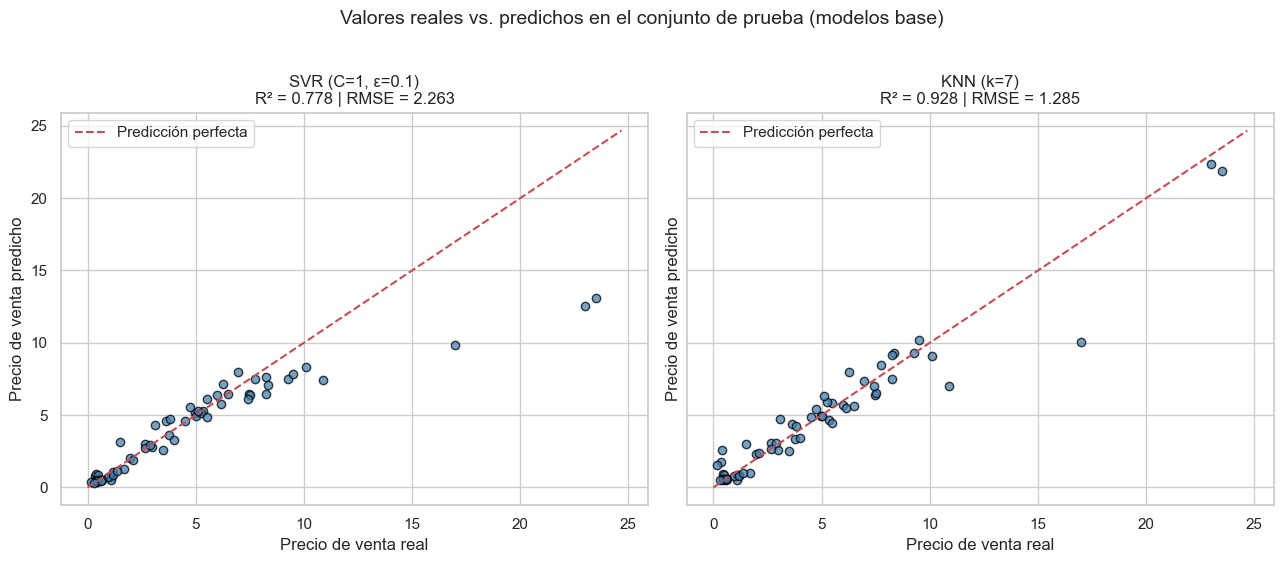

In [18]:
graficar_real_vs_predicho(
    {"SVR (C=1, ε=0.1)": pred_svr_base, "KNN (k=7)": pred_knn_base},
    "Valores reales vs. predichos en el conjunto de prueba (modelos base)"
)

**Interpretación del gráfico:** cuanto más cerca estén los puntos de la línea roja, mejor es la predicción.

- El **SVR base** se separa claramente de la diagonal en los precios altos: subestima sistemáticamente los autos caros (los puntos quedan por debajo de la línea), coherente con el subajuste detectado.
- El **KNN (k=7)** sigue la diagonal con mucha más fidelidad, incluso para los precios altos (las excepciones son pocos autos, como uno de precio real ≈ 17 que subestima).

**Con la configuración pedida en el enunciado, el KNN predice mejor el precio de venta** (R² de 0,93 frente a 0,78 y RMSE de 1,29 frente a 2,26). La razón es que el KNN se adapta localmente a los datos (autos parecidos tienen precios parecidos), mientras que el SVR con `C=1` y `epsilon=0.1` es demasiado rígido para esta escala de precios.

## Búsqueda de hiperparámetros con GridSearchCV (Caso 1)

Para no quedarnos solo con los parámetros fijos del enunciado, se exploran hiperparámetros con `GridSearchCV` y validación cruzada de 5 particiones (`cv=5`) sobre el **conjunto de entrenamiento**, usando R² como métrica de selección. El conjunto de prueba solo se usa al final para evaluar.

**Hiperparámetros explorados:**

| Modelo | Hiperparámetros |
|---|---|
| SVR | `kernel` (linear, rbf), `C` (0.1, 1, 10, 100), `epsilon` (0.01, 0.1, 0.5, 1), `gamma` (scale, 0.01, 0.1, 1) |
| KNN | `n_neighbors` (1 a 20), `weights` (uniform, distance), `p` (1 = distancia Manhattan, 2 = Euclidiana) |

In [19]:
param_grid_svr = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "gamma": ["scale", 0.01, 0.1, 1],
}

grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=5, scoring="r2", n_jobs=-1)
grid_svr.fit(X_train_r_sc, y_train_r)

print("=== GridSearchCV · SVR ===")
print(f"Mejores hiperparámetros : {grid_svr.best_params_}")
print(f"Mejor R² en validación cruzada: {grid_svr.best_score_:.4f}")

=== GridSearchCV · SVR ===
Mejores hiperparámetros : {'C': 100, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Mejor R² en validación cruzada: 0.9316


In [20]:
param_grid_knn = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}

grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring="r2", n_jobs=-1)
grid_knn.fit(X_train_r_sc, y_train_r)

print("=== GridSearchCV · KNN ===")
print(f"Mejores hiperparámetros : {grid_knn.best_params_}")
print(f"Mejor R² en validación cruzada: {grid_knn.best_score_:.4f}")

=== GridSearchCV · KNN ===
Mejores hiperparámetros : {'n_neighbors': 4, 'p': 2, 'weights': 'distance'}
Mejor R² en validación cruzada: 0.8742


Se evalúan en el conjunto de prueba los mejores modelos encontrados por cada búsqueda (`best_estimator_`), con las mismas métricas de antes.

In [21]:
svr_opt = grid_svr.best_estimator_
knn_opt = grid_knn.best_estimator_

_, pred_svr_opt = evaluar_regresion("SVR optimizado (GridSearchCV)", svr_opt)
_, pred_knn_opt = evaluar_regresion("KNN optimizado (GridSearchCV)", knn_opt)

tabla_regresion = pd.DataFrame(resultados_regresion).set_index("Modelo")
tabla_regresion.round(4)

,MSE,RMSE,MAE,R² prueba,R² entrenamiento,R² validación cruzada (5 folds)
Modelo,,,,,,
"SVR base (rbf, C=1, ε=0.1)",5.1198,2.2627,1.0108,0.7777,0.6565,0.6011
KNN base (k=7),1.6512,1.2850,0.7790,0.9283,0.8906,0.8305
SVR optimizado (GridSearchCV),1.1000,1.0488,0.6410,0.9522,0.9773,0.9316
KNN optimizado (GridSearchCV),1.2987,1.1396,0.6934,0.9436,1.0000,0.8742


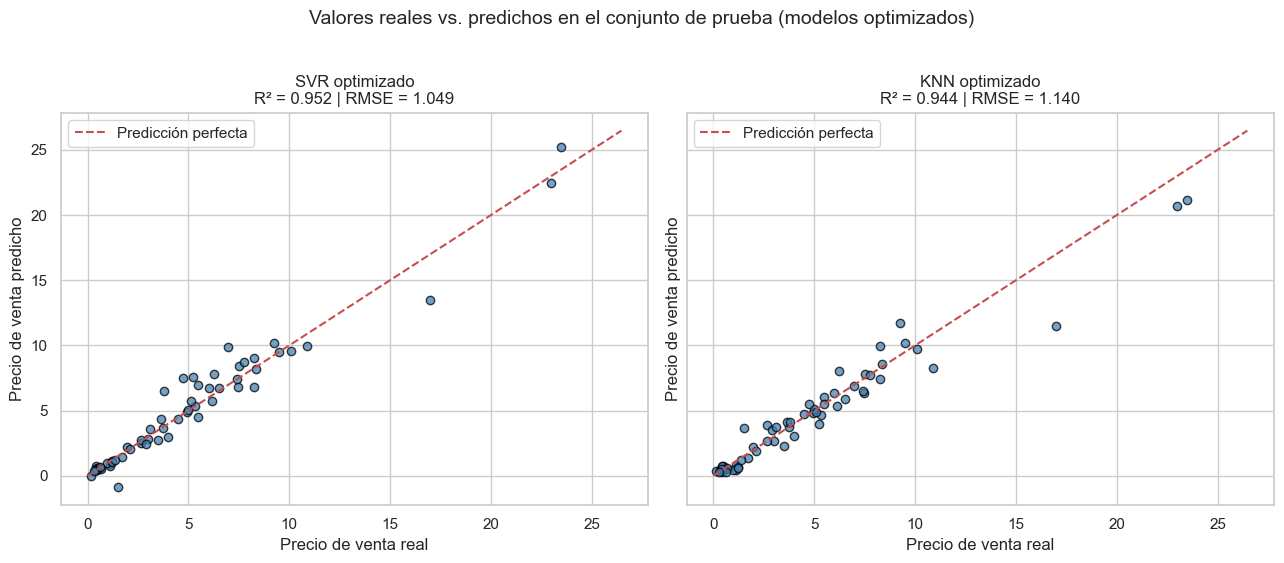

In [22]:
graficar_real_vs_predicho(
    {"SVR optimizado": pred_svr_opt, "KNN optimizado": pred_knn_opt},
    "Valores reales vs. predichos en el conjunto de prueba (modelos optimizados)"
)

### Interpretación de los modelos optimizados

- **SVR:** el mejor modelo usa `C=100`, `epsilon=0.1`, `gamma=0.01` y kernel `rbf`. Subir `C` de 1 a 100 permite al SVR ajustarse mucho mejor a los precios altos. El resultado mejora de forma notable: el R² en prueba pasa de ≈ 0,78 a ≈ 0,95 y el RMSE baja de ≈ 2,26 a ≈ 1,05. Además, el R² de entrenamiento (≈ 0,98) y el de prueba (≈ 0,95) son cercanos, por lo que **generaliza bien**. El subajuste inicial queda corregido.
- **KNN:** la búsqueda prefiere `n_neighbors=4`, `weights='distance'` y `p=2`. Mejora algo respecto a `k=7` (R² de prueba ≈ 0,94, RMSE ≈ 1,14). Sin embargo, su R² en entrenamiento es 1,0: con `weights='distance'` cada punto de entrenamiento es su propio vecino con peso máximo, por lo que "memoriza" el entrenamiento. Esa cifra no es informativa; lo relevante es el desempeño en validación cruzada.
- **Validación cruzada:** el SVR optimizado obtiene un R² de ≈ 0,93 en validación cruzada frente a ≈ 0,87 del KNN optimizado. El SVR es el modelo **más estable** al cambiar la partición de los datos.

Como el conjunto de prueba tiene solo 61 autos y algunos precios extremos pesan mucho en el MSE, se prefiere decidir con **ambos criterios** (prueba y validación cruzada) y no solo con la partición única.

### Comparación final de regresión (todos los modelos)

In [23]:
orden = ["MSE", "RMSE", "MAE", "R² prueba", "R² entrenamiento", "R² validación cruzada (5 folds)"]
tabla_regresion_final = tabla_regresion[orden].sort_values("RMSE")
tabla_regresion_final.round(4)

,MSE,RMSE,MAE,R² prueba,R² entrenamiento,R² validación cruzada (5 folds)
Modelo,,,,,,
SVR optimizado (GridSearchCV),1.1000,1.0488,0.6410,0.9522,0.9773,0.9316
KNN optimizado (GridSearchCV),1.2987,1.1396,0.6934,0.9436,1.0000,0.8742
KNN base (k=7),1.6512,1.2850,0.7790,0.9283,0.8906,0.8305
"SVR base (rbf, C=1, ε=0.1)",5.1198,2.2627,1.0108,0.7777,0.6565,0.6011


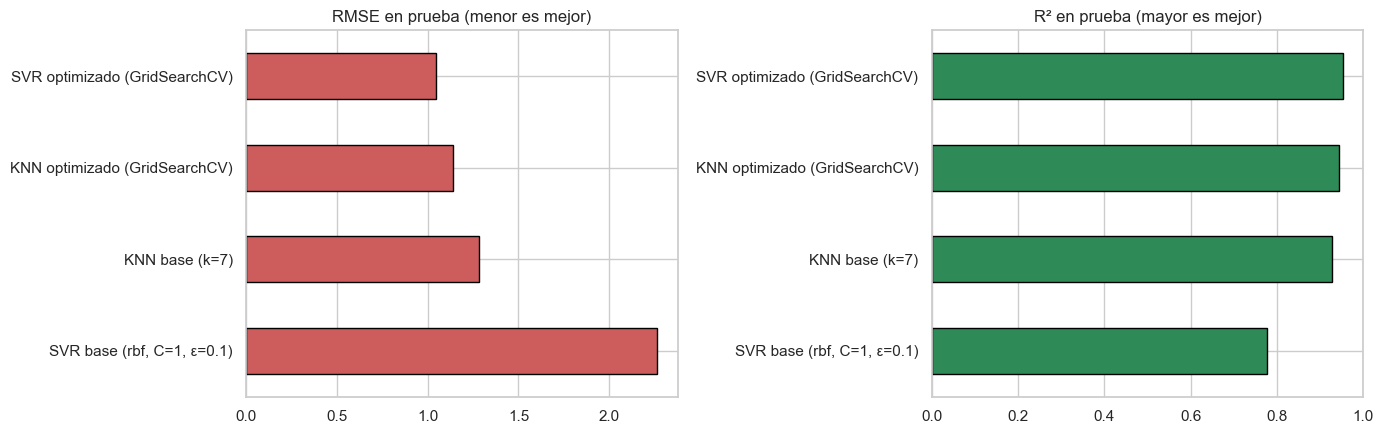

In [24]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.5))

tabla_regresion_final["RMSE"].plot(kind="barh", ax=ejes[0], color="indianred", edgecolor="black")
ejes[0].set_title("RMSE en prueba (menor es mejor)")
ejes[0].invert_yaxis()

tabla_regresion_final["R² prueba"].plot(kind="barh", ax=ejes[1], color="seagreen", edgecolor="black")
ejes[1].set_title("R² en prueba (mayor es mejor)")
ejes[1].set_xlim(0, 1)
ejes[1].invert_yaxis()

for eje in ejes:
    eje.set_ylabel("")
plt.tight_layout()
plt.show()

### Conclusión del Caso 1: ¿cuál modelo predice mejor?

1. **Con los parámetros fijos del enunciado**, el **KNN (k=7) predice mejor** que el SVR (R² 0,93 vs. 0,78; RMSE 1,29 vs. 2,26), porque el SVR con `C=1` queda subajustado.
2. **Después de explorar hiperparámetros**, el **SVR optimizado es el mejor modelo de regresión**: tiene el menor MSE/RMSE y el mayor R² en prueba (≈ 0,95), el mejor R² en validación cruzada (≈ 0,93) y no presenta sobreajuste. El KNN optimizado queda muy cerca en prueba, pero es menos estable en validación cruzada y memoriza el entrenamiento.
3. La lección es que **la comparación entre algoritmos depende de sus hiperparámetros**: con una configuración inadecuada, un buen algoritmo (SVR) parece peor que otro más simple (KNN).
4. Limitaciones: el dataset es pequeño (301 autos), `precio_actual` concentra gran parte del poder predictivo y los autos de precio muy alto son escasos, por lo que las predicciones en ese segmento son menos confiables.

# Caso 2 · Clasificación: predicción de cáncer de mama

## Contexto y objetivo

El cáncer de mama es un tipo de cáncer que se forma en las células de las mamas. Después del cáncer de piel, es el tipo más común diagnosticado en mujeres en todo el mundo. Puede presentarse tanto en hombres como en mujeres, aunque es mucho más común en las mujeres.

El considerable apoyo para la concientización y la financiación de investigaciones ha ayudado a crear avances en el diagnóstico y tratamiento de esta enfermedad. Las tasas de supervivencia han aumentado y el número de muertes asociadas está disminuyendo, en gran medida gracias a la detección temprana, a un enfoque de tratamiento personalizado y a una mejor comprensión de la enfermedad.

El dataset `breast_cancer.csv` contiene mediciones de las células de la masa mamaria, obtenidas a partir de imágenes digitalizadas.

**Objetivo de clasificación:** construir modelos que clasifiquen un tumor como **maligno (1)** o **benigno (0)** a partir de sus mediciones celulares (variable objetivo `diagnosis`), y compararlos con métricas adecuadas para un problema médico. En este contexto, el error más grave es el **falso negativo** (un tumor maligno clasificado como benigno), por lo que se dará especial atención al *recall* de la clase maligna.

## Carga de datos

Se crea una copia del archivo original para no alterarlo y se trabaja con ella.

In [25]:
df_breast = pd.read_csv("data_sets/breast_cancer.csv")

# Copia del archivo original (el original no se modifica)
shutil.copy("data_sets/breast_cancer.csv", "copy/breast_can_copy.csv")
df_breast_copia = pd.read_csv("copy/breast_can_copy.csv")

df_breast_copia.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Análisis exploratorio de los datos

Se revisa la cantidad de filas y columnas, los tipos de datos y la presencia de valores nulos.

In [26]:
print(f"Cantidad de columnas: {df_breast_copia.shape[1]}")
print(f"Cantidad de registros: {df_breast_copia.shape[0]}")

Cantidad de columnas: 32
Cantidad de registros: 569


In [27]:
df_breast_copia.dtypes.value_counts()

float64    30
int64       2
Name: count, dtype: int64

In [28]:
print(f"Columnas de tipo float: {sum(df_breast_copia.dtypes == 'float64')}")
print(f"Columnas de tipo entero: {sum(df_breast_copia.dtypes == 'int64')}")
print(f"Columnas de otro tipo: {df_breast_copia.select_dtypes(exclude=['float64', 'int64']).shape[1]}")

Columnas de tipo float: 30
Columnas de tipo entero: 2
Columnas de otro tipo: 0


### Revisión de valores nulos

In [29]:
nulos_por_columna = df_breast_copia.isnull().sum()
print(f"Columnas con valores nulos: {(nulos_por_columna > 0).sum()}")
print(f"Total de valores nulos en el dataset: {nulos_por_columna.sum()}")

Columnas con valores nulos: 0
Total de valores nulos en el dataset: 0


El dataset **no tiene valores nulos**, por lo que no requiere ningún tratamiento de datos faltantes. Todas las columnas son numéricas: 30 mediciones decimales, la columna `id` (entera) y la variable objetivo `diagnosis` (entera).

## Selección de datos

Se eliminan las columnas que no aportan información para predecir el diagnóstico:

- `id`: es solo un identificador del registro; no describe al tumor y podría introducir ruido.
- `Unnamed: 32`: columna vacía que suele aparecer en este dataset cuando proviene de otras fuentes. Se elimina solo si existe (en este archivo no está presente).

Las 30 mediciones restantes describen la forma y textura de los núcleos celulares (radio, textura, perímetro, área, suavidad, compacidad, concavidad, puntos cóncavos, simetría y dimensión fractal), cada una como promedio (`_mean`), error estándar (`_se`) y peor valor (`_worst`). Estas características se relacionan con los signos clínicos de un tumor maligno: cambios de tamaño y forma, y bordes irregulares.

In [30]:
df_breast_copia = df_breast_copia.drop(columns=["id"])

if "Unnamed: 32" in df_breast_copia.columns:
    df_breast_copia = df_breast_copia.drop(columns=["Unnamed: 32"])

print(f"Columnas 'id' o 'Unnamed' presentes: {[c for c in df_breast_copia.columns if c == 'id' or c.startswith('Unnamed')]}")
print(f"Forma del dataset: {df_breast_copia.shape}")
df_breast_copia.head()

Columnas 'id' o 'Unnamed' presentes: []
Forma del dataset: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Variable objetivo: `diagnosis`

### ¿Es necesario transformar las etiquetas?

La variable `diagnosis` ya viene codificada como **numérica binaria** (1 = maligno, 0 = benigno). Por lo tanto **no es necesario transformar las etiquetas** (por ejemplo, con `LabelEncoder`): los algoritmos de scikit-learn aceptan directamente 0 y 1. Además, esta codificación es conveniente porque la clase de interés, la maligna, es la clase positiva (1); así las métricas `precision`, `recall` y `F1` se interpretan directamente sobre los casos de cáncer.

### Distribución de las clases y balance

 - Benigno (0): 357 registros (62.74 %)
 - Maligno (1): 212 registros (37.26 %)

Razón entre la clase mayoritaria y la minoritaria: 1.68 : 1


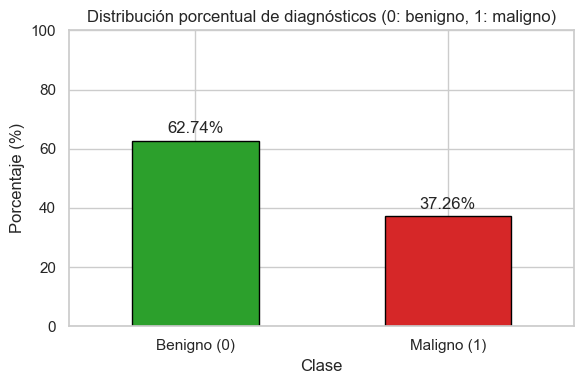

In [31]:
distribucion_porcentual = df_breast_copia["diagnosis"].value_counts(normalize=True) * 100
conteo_clases = df_breast_copia["diagnosis"].value_counts()

for clase, porcentaje in distribucion_porcentual.items():
    nombre_clase = "Maligno (1)" if clase == 1 else "Benigno (0)"
    print(f" - {nombre_clase}: {conteo_clases[clase]} registros ({porcentaje:.2f} %)")

print(f"\nRazón entre la clase mayoritaria y la minoritaria: {conteo_clases.max() / conteo_clases.min():.2f} : 1")

plt.figure(figsize=(6, 4))
ax = distribucion_porcentual.sort_index().plot(kind="bar", color=["#2ca02c", "#d62728"], edgecolor="black")
plt.title("Distribución porcentual de diagnósticos (0: benigno, 1: maligno)")
plt.xlabel("Clase")
plt.ylabel("Porcentaje (%)")
plt.xticks(ticks=[0, 1], labels=["Benigno (0)", "Maligno (1)"], rotation=0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha="center", va="bottom", xytext=(0, 3), textcoords="offset points")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

**Verificación del desbalance de clases:** hay 357 casos benignos (62,74 %) y 212 malignos (37,26 %), una razón de 1,68 : 1. Es un **desbalance leve a moderado**: la clase minoritaria sigue teniendo muchos ejemplos (212), por lo que no es necesario aplicar técnicas agresivas de remuestreo como SMOTE o submuestreo, que además descartarían datos o crearían registros sintéticos en un dataset ya pequeño.

En su lugar, se toman tres medidas:

1. **Partición estratificada** (`stratify=y`), para que entrenamiento y prueba mantengan la misma proporción 63/37.
2. **No usar solo la exactitud** (*accuracy*) para evaluar: un modelo que dijera siempre "benigno" tendría ~63 % de exactitud sin detectar ningún cáncer. Se reportan *precision*, *recall*, *F1* y *AUC* de la clase maligna.
3. **Comprobación experimental**: más adelante se entrena una regresión logística con `class_weight='balanced'` para verificar si balancear mejora el resultado.

## Correlación entre la variable objetivo y las predictoras

In [32]:
correlacion_diagnosis = df_breast_copia.corr()["diagnosis"].sort_values(ascending=False)
print("Correlación de las variables predictoras con 'diagnosis':\n")
print(correlacion_diagnosis.drop("diagnosis").round(4).to_string())

Correlación de las variables predictoras con 'diagnosis':

concave points_worst       0.7936
perimeter_worst            0.7829
concave points_mean        0.7766
radius_worst               0.7765
perimeter_mean             0.7426
area_worst                 0.7338
radius_mean                0.7300
area_mean                  0.7090
concavity_mean             0.6964
concavity_worst            0.6596
compactness_mean           0.5965
compactness_worst          0.5910
radius_se                  0.5671
perimeter_se               0.5561
area_se                    0.5482
texture_worst              0.4569
smoothness_worst           0.4215
symmetry_worst             0.4163
texture_mean               0.4152
concave points_se          0.4080
smoothness_mean            0.3586
symmetry_mean              0.3305
fractal_dimension_worst    0.3239
compactness_se             0.2930
concavity_se               0.2537
fractal_dimension_se       0.0780
symmetry_se               -0.0065
texture_se             

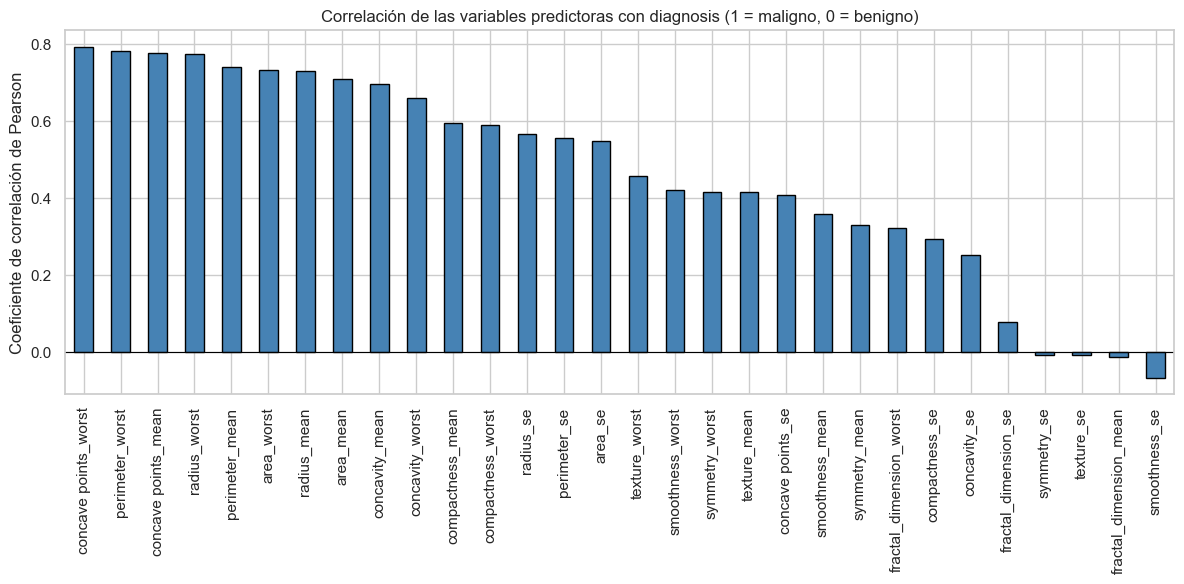

In [33]:
plt.figure(figsize=(12, 6))
correlacion_diagnosis.drop("diagnosis").plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Correlación de las variables predictoras con diagnosis (1 = maligno, 0 = benigno)")
plt.ylabel("Coeficiente de correlación de Pearson")
plt.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

La gran mayoría de las variables tiene correlación positiva con el diagnóstico: valores más altos de tamaño, concavidad y puntos cóncavos se asocian a tumores malignos. Solo unas pocas variables (`fractal_dimension_mean`, `texture_se`, `symmetry_se`, `smoothness_se`) tienen correlación cercana a cero o levemente negativa, y su efecto es pequeño.

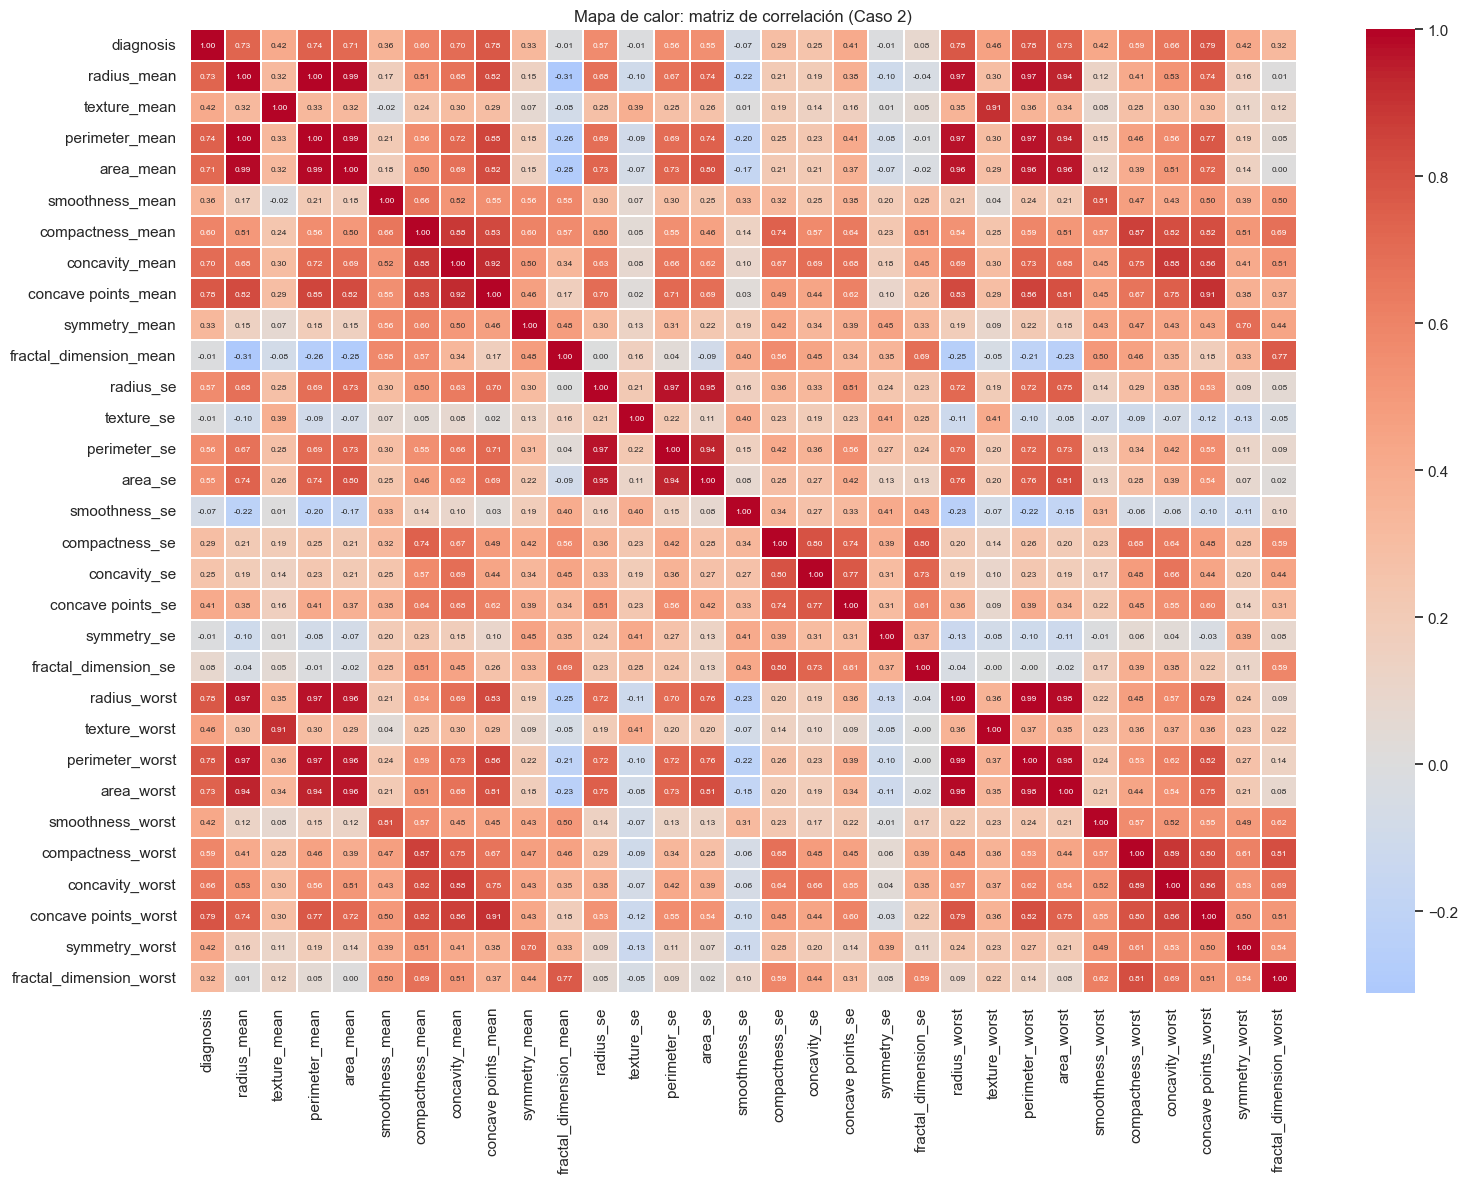

In [34]:
matriz_correlacion = df_breast_copia.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(matriz_correlacion, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            annot_kws={"size": 6}, linewidths=0.3)
plt.title("Mapa de calor: matriz de correlación (Caso 2)")
plt.tight_layout()
plt.show()

El mapa de calor muestra bloques de variables **muy correlacionadas entre sí**, sobre todo las que miden el tamaño de la célula (radio, perímetro y área). Esto es un indicio de **multicolinealidad**.

## Análisis de multicolinealidad

> "La multicolinealidad es un fenómeno estadístico que ocurre cuando dos o más variables independientes en un modelo de regresión están altamente correlacionadas, lo que significa que una puede predecirse linealmente a partir de las demás con un grado sustancial de precisión."

En este dataset, el radio, el perímetro y el área son medidas del tamaño de una misma célula y, matemáticamente, se derivan unas de otras (el perímetro y el área crecen con el radio). Para cuantificar el problema se usa el **factor de inflación de varianza (VIF)**:

> "Un factor de inflación de varianza (VIF) proporciona una medida de multicolinealidad entre las variables independientes en un modelo de regresión múltiple. Mide cuánto se infla la varianza de una estimación de coeficiente debido a la multicolinealidad."

Como regla general, un VIF superior a 10 indica multicolinealidad relevante. Se calcula primero con el dataset original (sin `id` ni `diagnosis`).

In [35]:
def calcular_vif(df_predictoras):
    """Devuelve una tabla con el VIF de cada variable, ordenada de mayor a menor."""
    tabla = pd.DataFrame({"Variable predictora": df_predictoras.columns})
    tabla["Valor VIF"] = [variance_inflation_factor(df_predictoras.values, i)
                          for i in range(df_predictoras.shape[1])]
    return tabla.sort_values("Valor VIF", ascending=False).reset_index(drop=True)


vif_original = calcular_vif(df_breast.drop(columns=["id", "diagnosis"]))
print("VIF con el dataset original (30 predictoras):")
print(vif_original.head(12).to_string())
print(f"\nVariables con VIF > 10: {(vif_original['Valor VIF'] > 10).sum()} de {len(vif_original)}")

VIF con el dataset original (30 predictoras):
    Variable predictora    Valor VIF
0           radius_mean  3806.115296
1        perimeter_mean  3786.400419
2          radius_worst   799.105946
3       perimeter_worst   405.023336
4             area_mean   347.878657
5            area_worst   337.221924
6             radius_se    75.462027
7        concavity_mean    70.767720
8          perimeter_se    70.359695
9   concave points_mean    60.041733
10     compactness_mean    50.505168
11              area_se    41.163091

Variables con VIF > 10: 23 de 30


Los valores son extremos: `radius_mean` y `perimeter_mean` superan un VIF de 3.800. Esto confirma que muchas variables son **altamente redundantes**.

### Uso del área como única medida de tamaño

Para reducir la redundancia se conserva únicamente la variable de **área** y se eliminan las de **radio** y **perímetro**. El área mide la totalidad del espacio bidimensional que ocupa la célula: cuando una célula muta y forma un bulto anormal, todo su cuerpo exige más espacio físico, y el área captura esa magnitud total de forma más completa que el radio o el perímetro.

In [36]:
columnas_geometria_basica = [col for col in df_breast_copia.columns if "radius" in col or "perimeter" in col]
df_limpio = df_breast_copia.drop(columns=columnas_geometria_basica)

print(f"Columnas eliminadas ({len(columnas_geometria_basica)}): {columnas_geometria_basica}")
print(f"Columnas restantes: {df_limpio.shape[1]} (24 predictoras + diagnosis)")

Columnas eliminadas (6): ['radius_mean', 'perimeter_mean', 'radius_se', 'perimeter_se', 'radius_worst', 'perimeter_worst']
Columnas restantes: 25 (24 predictoras + diagnosis)


### Justificación de mantener las variables `_worst` y `_se`

Se conservan las variables de **error estándar** y de **peor valor** porque capturan comportamientos que el promedio (`_mean`) diluye:

- **Error estándar (`_se`) para detectar la heterogeneidad tumoral:** cuantifica el desorden dentro de la misma muestra de tejido. Un tejido benigno tiene células uniformes y ordenadas (variación cercana a cero), mientras que el desarrollo maligno es desordenado. A mayor error estándar, mayor irregularidad del tejido.
- **Peor valor (`_worst`) para aislar anomalías extremas:** es la media de los tres valores más grandes encontrados para cada característica en la imagen. Expone la gravedad localizada del tejido al enfocarse en las células más irregulares de la muestra.

Se recalcula el VIF con el dataset ya reducido para verificar el efecto.

In [37]:
vif_limpio = calcular_vif(df_limpio.drop(columns=["diagnosis"]))
print("VIF con el dataset limpio (24 predictoras):")
print(vif_limpio.head(12).to_string())
print(f"\nVariables con VIF > 10: {(vif_limpio['Valor VIF'] > 10).sum()} de {len(vif_limpio)}")
print(f"VIF máximo: original = {vif_original['Valor VIF'].max():.0f} -> limpio = {vif_limpio['Valor VIF'].max():.0f}")

VIF con el dataset limpio (24 predictoras):
        Variable predictora  Valor VIF
0            concavity_mean  63.714355
1       concave points_mean  57.236099
2         compactness_worst  34.168224
3      concave points_worst  33.579946
4           concavity_worst  31.519447
5          compactness_mean  28.375536
6                 area_mean  25.140127
7                area_worst  21.095159
8   fractal_dimension_worst  18.230336
9             texture_worst  17.689321
10           compactness_se  14.809190
11             concavity_se  14.312045

Variables con VIF > 10: 15 de 24
VIF máximo: original = 3806 -> limpio = 64


El VIF máximo baja de ≈ 3.800 a ≈ 64 y la cantidad de variables con VIF > 10 baja de 23 (de 30) a 15 (de 24). **Aún quedan variables con VIF > 10** (concavidad, compacidad y puntos cóncavos, que miden aspectos parecidos del contorno), pero la reducción es drástica y suficiente para este trabajo: para fines de **predicción** la multicolinealidad residual no invalida el modelo, solo dificulta interpretar los coeficientes de forma individual. Además, los árboles de decisión no se ven afectados por este fenómeno.

## Análisis de valores atípicos (outliers)

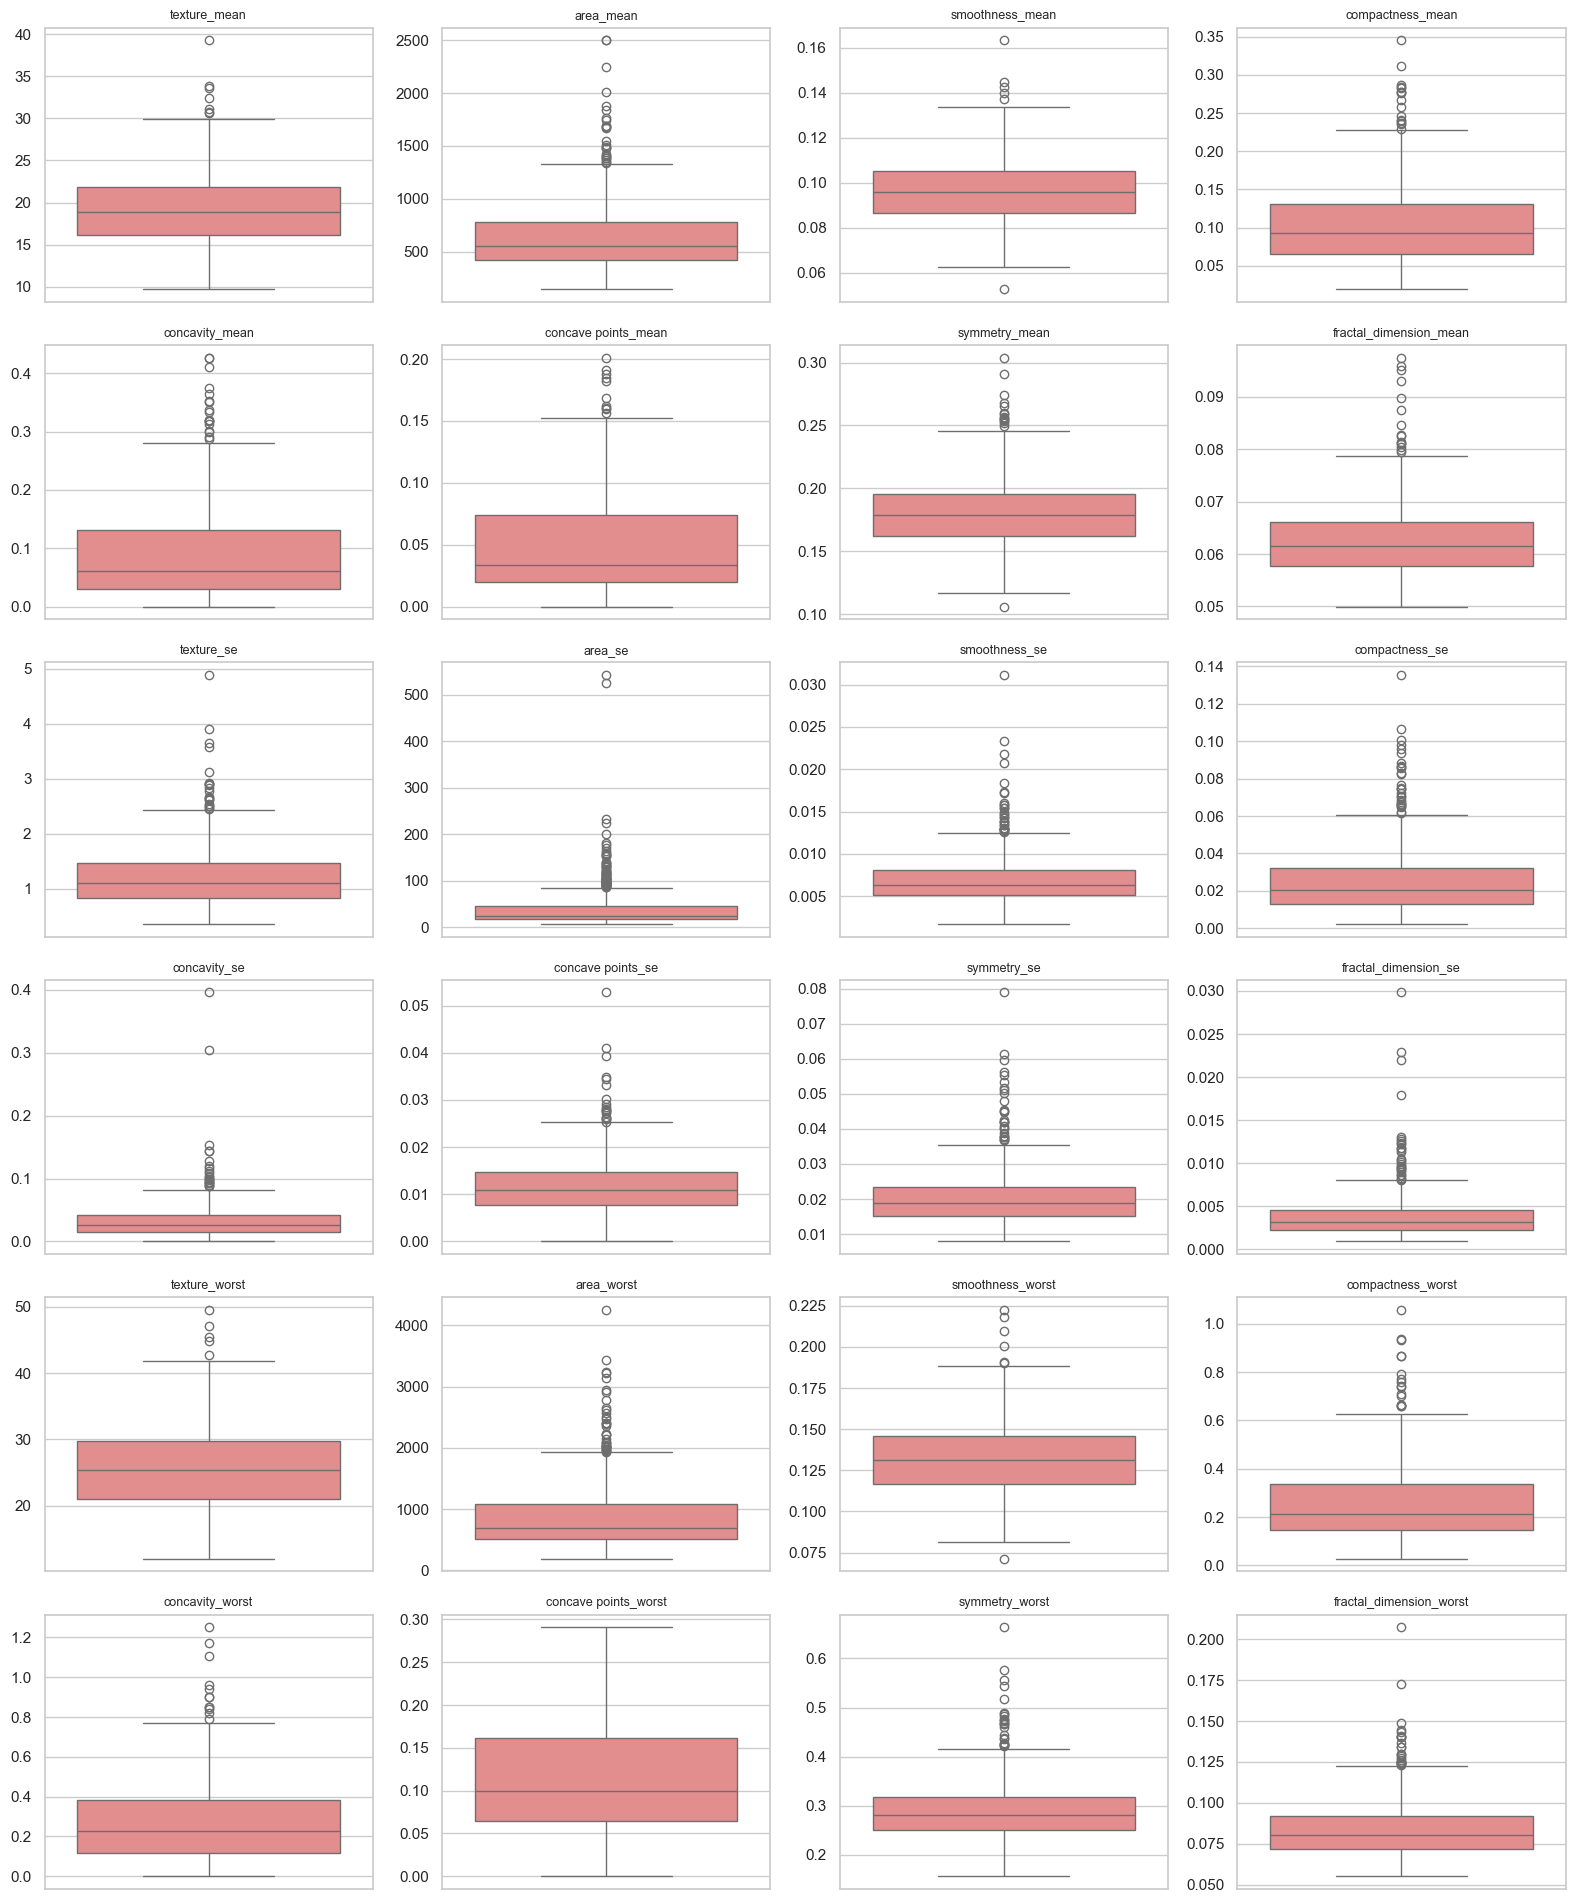

In [38]:
columnas_predictoras = [col for col in df_limpio.columns if col != "diagnosis"]
n_cols = 4
n_filas = math.ceil(len(columnas_predictoras) / n_cols)

plt.figure(figsize=(16, n_filas * 3.2))
for i, col in enumerate(columnas_predictoras, 1):
    plt.subplot(n_filas, n_cols, i)
    sns.boxplot(y=df_limpio[col], color="lightcoral")
    plt.title(col, fontsize=9)
    plt.ylabel("")
plt.tight_layout()
plt.show()

Hay valores atípicos en muchas variables, pero **se mantienen**: corresponden en su mayoría a tumores malignos con características extremas, que son justamente los casos que el modelo debe aprender a detectar. Eliminarlos reduciría el dataset (569 registros) y sesgaría el modelo hacia los casos benignos. Se decide dejar los datos intactos en este aspecto.

## Comparación del dataset original y el dataset limpio

In [39]:
print(f"Columnas del dataset original (sin id, incluye diagnosis): {df_breast.shape[1] - 1}")
print(f"Columnas del dataset limpio (incluye diagnosis)      : {df_limpio.shape[1]}")
print(f"Columnas eliminadas                                  : {df_breast.shape[1] - 1 - df_limpio.shape[1]}")
print(f"Registros (sin cambios)                              : {df_breast.shape[0]} -> {df_limpio.shape[0]}")

Columnas del dataset original (sin id, incluye diagnosis): 31
Columnas del dataset limpio (incluye diagnosis)      : 25
Columnas eliminadas                                  : 6
Registros (sin cambios)                              : 569 -> 569


## Partición en entrenamiento y prueba

Se separan los datos en 80 % para entrenamiento y 20 % para prueba. Con `random_state=42` la partición es reproducible y con `stratify=y` se mantiene la misma proporción de casos benignos y malignos en ambos conjuntos, lo que es importante dado el desbalance leve de las clases.

In [40]:
X = df_limpio.drop(columns=["diagnosis"])
y = df_limpio["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Registros de entrenamiento: {len(X_train)} | Registros de prueba: {len(X_test)}")
print("\nProporción de la clase maligna:")
print(f" - dataset completo: {y.mean() * 100:.2f} %")
print(f" - entrenamiento   : {y_train.mean() * 100:.2f} %")
print(f" - prueba          : {y_test.mean() * 100:.2f} %")

Registros de entrenamiento: 455 | Registros de prueba: 114

Proporción de la clase maligna:
 - dataset completo: 37.26 %
 - entrenamiento   : 37.36 %
 - prueba          : 36.84 %


Primeros 10 valores de cada conjunto:

In [41]:
print("X_train (primeros 10 registros):")
X_train.head(10)

X_train (primeros 10 registros):


,texture_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,23.24,797.8,0.08206,0.06669,0.03299,0.03323,0.1528,0.05697,1.1870,40.51,0.004029,0.009269,0.01101,0.007591,0.01460,0.003042,33.88,1150.0,0.11810,0.1551,0.1459,0.09975,0.2948,0.08452
170,12.39,464.1,0.10280,0.06981,0.03987,0.03700,0.1959,0.05955,0.6656,17.43,0.008045,0.011800,0.01683,0.012410,0.01924,0.002248,15.64,549.1,0.13850,0.1266,0.1242,0.09391,0.2827,0.06771
407,21.37,514.5,0.07551,0.08316,0.06126,0.01867,0.1580,0.06114,1.7980,41.24,0.006011,0.044800,0.05175,0.013410,0.02669,0.007731,27.01,645.8,0.09402,0.1936,0.1838,0.05601,0.2488,0.08151
430,22.53,685.0,0.09947,0.22250,0.27330,0.09711,0.2041,0.06898,0.8749,24.19,0.006965,0.062130,0.07926,0.022340,0.01499,0.005784,27.57,832.7,0.14190,0.7090,0.9019,0.24750,0.2866,0.11550
27,20.25,1094.0,0.09440,0.10660,0.14900,0.07731,0.1697,0.05699,1.8490,93.54,0.010750,0.027220,0.05081,0.019110,0.02293,0.004217,27.26,1403.0,0.13380,0.2117,0.3446,0.14900,0.2341,0.07421
212,18.47,2499.0,0.11420,0.15160,0.32010,0.15950,0.1648,0.05525,1.4760,525.60,0.013450,0.027720,0.06389,0.014070,0.04783,0.004476,18.47,2499.0,0.11420,0.1516,0.3201,0.15950,0.1648,0.05525
84,15.65,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,1.2550,16.16,0.005969,0.018120,0.02007,0.007027,0.01972,0.002607,24.90,567.9,0.13770,0.2003,0.2267,0.07632,0.3379,0.07924
36,21.72,633.0,0.09823,0.10980,0.13190,0.05598,0.1885,0.06125,1.0190,24.91,0.005878,0.029950,0.04815,0.011610,0.02028,0.004022,30.36,799.6,0.14460,0.4238,0.5186,0.14470,0.3591,0.10140
171,19.63,565.4,0.09048,0.06288,0.05858,0.03438,0.1598,0.05671,1.1470,43.40,0.006003,0.010630,0.02151,0.009443,0.01520,0.001868,29.87,993.6,0.14010,0.1546,0.2644,0.11600,0.2884,0.07371
237,21.46,1306.0,0.08355,0.08348,0.09042,0.06022,0.1467,0.05177,1.0410,83.50,0.007959,0.031330,0.04257,0.016710,0.01341,0.003933,26.17,1750.0,0.12280,0.2311,0.3158,0.14450,0.2238,0.07127


In [42]:
print("X_test (primeros 10 registros):")
X_test.head(10)

X_test (primeros 10 registros):


,texture_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,texture_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,texture_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
120,10.82,403.3,0.09373,0.06685,0.03512,0.02623,0.1667,0.06113,0.4607,10.50,0.006040,0.01529,0.015140,0.006460,0.01344,0.002206,15.97,510.5,0.1548,0.2390,0.21020,0.08958,0.3016,0.08523
250,23.56,1364.0,0.10070,0.16060,0.27120,0.13100,0.2205,0.05898,0.8208,137.90,0.005283,0.03908,0.095180,0.018640,0.02401,0.005002,27.00,2010.0,0.1211,0.3172,0.69910,0.21050,0.3126,0.07849
375,16.07,788.5,0.09880,0.14380,0.06651,0.05397,0.1990,0.06572,0.4890,14.91,0.004510,0.01812,0.019510,0.011960,0.01934,0.003696,19.14,861.5,0.1235,0.2550,0.21140,0.12510,0.3153,0.08960
99,19.77,642.5,0.09752,0.11410,0.09388,0.05839,0.1879,0.06390,1.8510,26.85,0.008005,0.02895,0.033210,0.014240,0.01462,0.004452,30.86,826.4,0.1431,0.3026,0.31940,0.15650,0.2718,0.09353
455,30.72,557.2,0.09245,0.07426,0.02819,0.03264,0.1375,0.06016,1.9240,28.93,0.005841,0.01246,0.007936,0.009128,0.01564,0.002985,41.61,705.6,0.1172,0.1421,0.07003,0.07763,0.2196,0.07675
318,18.90,244.5,0.09968,0.19720,0.19750,0.04908,0.2330,0.08743,1.9110,24.20,0.009845,0.06590,0.102700,0.025270,0.03491,0.007877,23.40,297.1,0.1221,0.3748,0.46090,0.11450,0.3135,0.10550
39,20.82,559.2,0.10160,0.12550,0.10630,0.05439,0.1720,0.06419,0.5914,18.52,0.005367,0.02239,0.030490,0.012620,0.01377,0.003187,26.02,740.4,0.1610,0.4225,0.50300,0.22580,0.2807,0.10710
371,13.21,711.8,0.07963,0.06934,0.03393,0.02657,0.1721,0.05544,0.4125,17.72,0.005012,0.01485,0.015510,0.009155,0.01647,0.001767,15.73,819.1,0.1126,0.1737,0.13620,0.08178,0.2487,0.06766
98,12.84,412.6,0.08983,0.07525,0.04196,0.03350,0.1620,0.06582,0.5391,15.75,0.006153,0.01330,0.016930,0.006884,0.01651,0.002551,17.16,512.5,0.1431,0.1851,0.19220,0.08449,0.2772,0.08756
502,16.32,476.3,0.11580,0.10850,0.05928,0.03279,0.1943,0.06612,1.0950,18.49,0.009702,0.01567,0.025750,0.011610,0.02801,0.002480,21.40,552.0,0.1580,0.1751,0.18890,0.08411,0.3155,0.07538


In [43]:
print("y_train (primeros 10 valores):")
y_train.head(10).to_frame()

y_train (primeros 10 valores):


,diagnosis
10,1
170,0
407,0
430,1
27,1
212,1
84,0
36,1
171,1
237,1


In [44]:
print("y_test (primeros 10 valores):")
y_test.head(10).to_frame()

y_test (primeros 10 valores):


,diagnosis
120,0
250,1
375,0
99,1
455,0
318,0
39,1
371,0
98,0
502,0


## ¿Es necesario escalar los datos?

Se comparan las magnitudes de las variables predictoras del conjunto de entrenamiento.

In [45]:
resumen_escalas = X_train.describe().T[["min", "mean", "std", "max"]]
resumen_escalas.columns = ["Mínimo", "Media", "Desv. estándar", "Máximo"]
resumen_escalas.round(4)

,Mínimo,Media,Desv. estándar,Máximo
texture_mean,9.7100,19.4177,4.2907,39.2800
area_mean,143.5000,659.5782,360.4187,2501.0000
smoothness_mean,0.0625,0.0960,0.0143,0.1634
compactness_mean,0.0194,0.1038,0.0539,0.3454
concavity_mean,0.0000,0.0892,0.0817,0.4268
concave points_mean,0.0000,0.0490,0.0397,0.2012
symmetry_mean,0.1060,0.1815,0.0276,0.3040
fractal_dimension_mean,0.0502,0.0627,0.0070,0.0974
texture_se,0.3602,1.2179,0.5523,4.8850
area_se,6.8020,41.2791,48.3842,542.2000


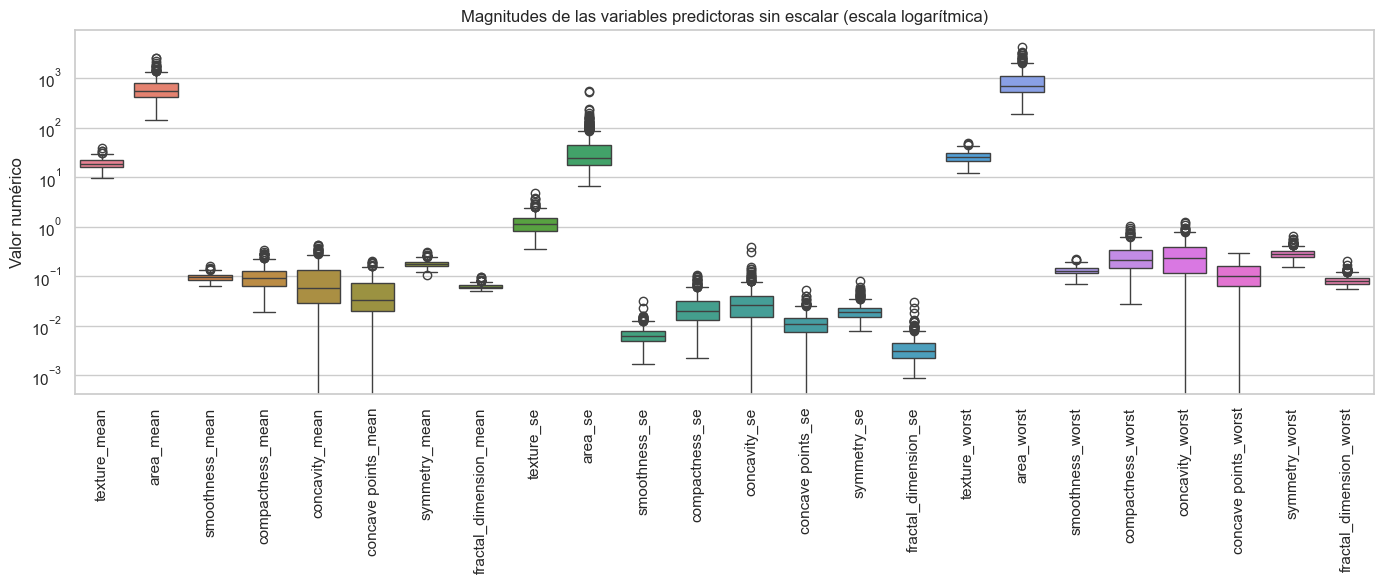

In [46]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.title("Magnitudes de las variables predictoras sin escalar (escala logarítmica)")
plt.ylabel("Valor numérico")
plt.yscale("log")
plt.tight_layout()
plt.show()

Las variables tienen magnitudes muy distintas: `area_mean` y `area_worst` llegan a miles, mientras que `smoothness_se` o `fractal_dimension_se` están en el orden de 0,001. Sin escalar, la regresión logística (que se optimiza con gradiente y es sensible a la escala) daría más peso a las variables de mayor magnitud. **Es necesario escalar.**

Se usa `MinMaxScaler`, que lleva todas las variables al rango [0, 1]. El escalador se ajusta **solo con el entrenamiento** y se aplica luego a la prueba, para evitar fuga de información.

In [47]:
escalador = MinMaxScaler()
X_train_scaled = escalador.fit_transform(X_train)   # fit solo con entrenamiento
X_test_scaled = escalador.transform(X_test)

print("Primer registro de entrenamiento escalado:")
print(np.round(X_train_scaled[0], 4))
print("\nPrimer registro de prueba escalado:")
print(np.round(X_test_scaled[0], 4))

Primer registro de entrenamiento escalado:
[0.4576 0.2775 0.1938 0.1451 0.0773 0.1652 0.2364 0.1426 0.1827 0.063
 0.0787 0.0674 0.0278 0.1438 0.0945 0.0742 0.5826 0.2371 0.3099 0.124
 0.1165 0.3428 0.2726 0.1934]

Primer registro de prueba escalado:
[0.0375 0.1102 0.3094 0.1456 0.0823 0.1304 0.3066 0.2307 0.0222 0.0069
 0.1471 0.1252 0.0382 0.1224 0.0782 0.0453 0.1053 0.0799 0.5523 0.2054
 0.1679 0.3078 0.286  0.198 ]


Los valores quedan en el rango [0, 1]. En la prueba pueden aparecer valores levemente fuera de ese rango si un dato supera el máximo del entrenamiento, lo cual es normal.

> Los árboles de decisión no necesitan escalamiento (sus cortes no dependen de la escala), pero se les entrega el mismo conjunto escalado para comparar todos los modelos sobre exactamente los mismos datos; esto no altera su resultado.

## Modelo 1: Regresión Logística

La regresión logística es un algoritmo de clasificación que estima la **probabilidad** de pertenecer a la clase positiva (maligno) y la convierte en una clase discreta (0 o 1) con un umbral de 0,5. Es adecuada para este problema binario. Se entrena con `solver='lbfgs'` como pide el enunciado.

In [48]:
modelo_logistico = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)
modelo_logistico.fit(X_train_scaled, y_train)

print("Modelo de regresión logística entrenado con éxito.")
print(f"Clases aprendidas por el modelo: {modelo_logistico.classes_}")

Modelo de regresión logística entrenado con éxito.
Clases aprendidas por el modelo: [0 1]


### Reporte de clasificación

In [49]:
y_pred = modelo_logistico.predict(X_test_scaled)

print("Classification Report · Regresión Logística (conjunto de prueba):")
print(classification_report(y_test, y_pred, target_names=["Benigno (0)", "Maligno (1)"], digits=4))

Classification Report · Regresión Logística (conjunto de prueba):
              precision    recall  f1-score   support

 Benigno (0)     0.9730    1.0000    0.9863        72
 Maligno (1)     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114



**Interpretación:**

- **Precision:** cuando el modelo dice "benigno" acierta el 97 % de las veces, y cuando dice "maligno" acierta el 100 % (ninguna falsa alarma).
- **Recall:** detecta el 100 % de los tumores benignos y el **95,2 % de los malignos**; es decir, se le escapan 2 de 42 tumores malignos.
- **F1:** 0,986 en la clase benigna y 0,976 en la maligna.
- **Exactitud global:** 98,25 %. Como el promedio de ambas clases (macro) también es alto, el rendimiento es bueno para las dos clases y no solo para la mayoritaria.

El punto más débil es el *recall* de la clase maligna, que es justamente la métrica más crítica en diagnóstico médico.

### Verificación de sobreajuste (overfitting)

Como los resultados son muy buenos, se comprueba que no haya sobreajuste comparando la exactitud en entrenamiento y en prueba.

In [50]:
acc_train_log = accuracy_score(y_train, modelo_logistico.predict(X_train_scaled))
acc_test_log = accuracy_score(y_test, modelo_logistico.predict(X_test_scaled))

print(f"Exactitud en entrenamiento: {acc_train_log * 100:.2f} %")
print(f"Exactitud en prueba       : {acc_test_log * 100:.2f} %")
print(f"Diferencia (brecha)       : {abs(acc_train_log - acc_test_log) * 100:.2f} puntos")

Exactitud en entrenamiento: 96.04 %
Exactitud en prueba       : 98.25 %
Diferencia (brecha)       : 2.20 puntos


La exactitud en prueba (98,25 %) es incluso **superior** a la de entrenamiento (96,04 %). Un modelo sobreajustado tendría el patrón inverso (muy alta en entrenamiento y baja en prueba), por lo que **se descarta el sobreajuste**. La diferencia a favor de la prueba se explica por el tamaño pequeño del conjunto de prueba (114 registros): 2 errores bastan para que cambien varias décimas. La validación cruzada (más adelante) confirma una exactitud de ≈ 95 %.

### Matriz de confusión

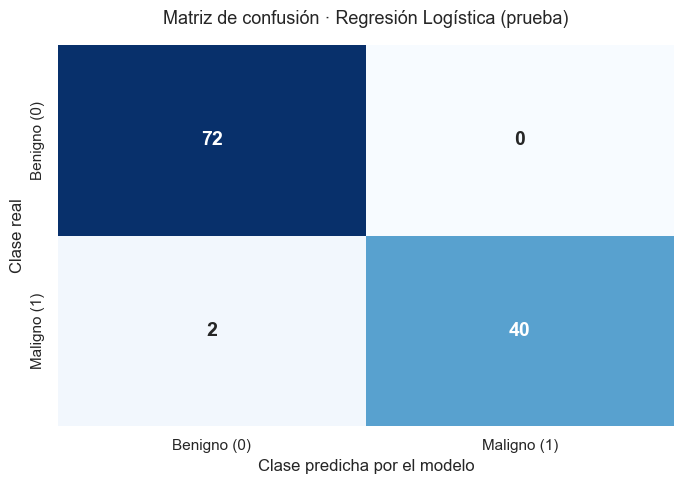

Verdaderos negativos (TN, benignos bien clasificados) : 72
Falsos positivos     (FP, falsa alarma)               : 0
Falsos negativos     (FN, cáncer no detectado)        : 2
Verdaderos positivos (TP, malignos bien clasificados) : 40


In [51]:
matriz_confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(matriz_confusion, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Benigno (0)", "Maligno (1)"], yticklabels=["Benigno (0)", "Maligno (1)"],
            annot_kws={"size": 14, "weight": "bold"})
plt.title("Matriz de confusión · Regresión Logística (prueba)", fontsize=13, pad=15)
plt.xlabel("Clase predicha por el modelo")
plt.ylabel("Clase real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = matriz_confusion.ravel()
print(f"Verdaderos negativos (TN, benignos bien clasificados) : {tn}")
print(f"Falsos positivos     (FP, falsa alarma)               : {fp}")
print(f"Falsos negativos     (FN, cáncer no detectado)        : {fn}")
print(f"Verdaderos positivos (TP, malignos bien clasificados) : {tp}")

**Interpretación:** de los 114 pacientes de prueba, el modelo clasificó bien a 112. Acertó los 72 casos benignos y 40 de los 42 malignos. No cometió falsos positivos y solo tuvo **2 falsos negativos** (tumores malignos clasificados como benignos), un margen de error muy bajo.

### Curva ROC y área bajo la curva (AUC)

La curva ROC muestra cómo cambian la tasa de verdaderos positivos (*recall*) y la de falsos positivos al variar el umbral de decisión. El **AUC** resume la curva en un número: es la probabilidad de que el modelo asigne una probabilidad mayor a un tumor maligno que a uno benigno elegidos al azar. Un AUC de 0,5 equivale a adivinar y de 1,0 es un clasificador perfecto.

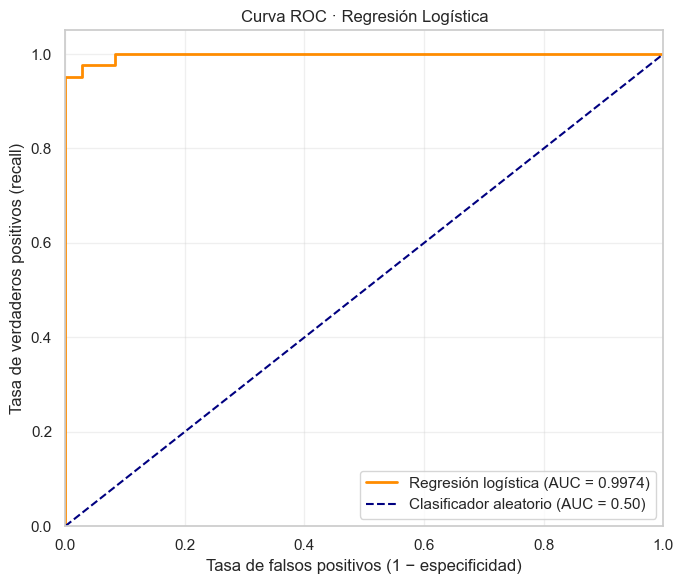

In [52]:
y_probs_log = modelo_logistico.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, umbrales = roc_curve(y_test, y_probs_log)
auc_log = roc_auc_score(y_test, y_probs_log)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"Regresión logística (AUC = {auc_log:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Clasificador aleatorio (AUC = 0.50)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Tasa de falsos positivos (1 − especificidad)")
plt.ylabel("Tasa de verdaderos positivos (recall)")
plt.title("Curva ROC · Regresión Logística")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretación:** la curva se pega a la esquina superior izquierda, muy lejos de la diagonal del azar. El AUC de **0,9974** indica una capacidad de discriminación casi perfecta: el modelo separa casi siempre los tumores malignos de los benignos, independientemente del umbral elegido.

### Experimento sobre el desbalance: regresión logística con `class_weight='balanced'`

Para comprobar si el leve desbalance de clases afecta al modelo, se entrena la misma regresión logística pero ponderando más a la clase minoritaria (maligna) y se comparan los resultados.

In [53]:
modelo_balanceado = LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42,
                                       class_weight="balanced")
modelo_balanceado.fit(X_train_scaled, y_train)
y_pred_bal = modelo_balanceado.predict(X_test_scaled)

comparacion_balance = pd.DataFrame({
    "Modelo": ["Sin balancear", "class_weight='balanced'"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_bal)],
    "Precision (maligno)": [precision_score(y_test, y_pred), precision_score(y_test, y_pred_bal)],
    "Recall (maligno)": [recall_score(y_test, y_pred), recall_score(y_test, y_pred_bal)],
    "F1 (maligno)": [f1_score(y_test, y_pred), f1_score(y_test, y_pred_bal)],
    "Falsos negativos": [confusion_matrix(y_test, y_pred)[1, 0], confusion_matrix(y_test, y_pred_bal)[1, 0]],
}).set_index("Modelo")
comparacion_balance.round(4)

,Accuracy,Precision (maligno),Recall (maligno),F1 (maligno),Falsos negativos
Modelo,,,,,
Sin balancear,0.9825,1.0,0.9524,0.9756,2
class_weight='balanced',0.9825,1.0,0.9524,0.9756,2


Las métricas son prácticamente las mismas con y sin balanceo, por lo que **el desbalance leve del dataset no perjudica al modelo** y no se justifica aplicar técnicas de balanceo. Se continúa con los modelos sin ponderar y con partición estratificada.

## Optimización de hiperparámetros con GridSearchCV

`GridSearchCV` es una herramienta de optimización de hiperparámetros que busca de forma exhaustiva la mejor combinación de parámetros para un modelo, utilizando validación cruzada. Prueba todas las combinaciones de los valores indicados y escoge la que maximiza una métrica de desempeño específica (aquí, la exactitud).

Se prueban `max_iter` en [50, 100, 150, 200] y `solver` en [newton-cg, lbfgs, liblinear, sag, saga], con `cv=5` y `scoring='accuracy'`, sobre los datos de entrenamiento escalados. Algunas combinaciones (por ejemplo `sag`/`saga` con pocas iteraciones) no alcanzan a converger y generan advertencias; se silencian porque son esperables y la búsqueda las evalúa igualmente.

In [54]:
param_grid_log = {
    "max_iter": [50, 100, 150, 200],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"],
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_log,
    cv=5,
    scoring="accuracy",
    n_jobs=1,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_search.fit(X_train_scaled, y_train)

print("=== Resultados de GridSearchCV · Regresión Logística ===")
print(f"Mejores hiperparámetros          : {grid_search.best_params_}")
print(f"Mejor exactitud en validación cruzada (entrenamiento): {grid_search.best_score_ * 100:.2f} %")

=== Resultados de GridSearchCV · Regresión Logística ===
Mejores hiperparámetros          : {'max_iter': 50, 'solver': 'newton-cg'}
Mejor exactitud en validación cruzada (entrenamiento): 95.38 %


### Resultados con el mejor modelo

Se evalúa en prueba el mejor modelo encontrado (`best_estimator_`) y se compara con el modelo base.

In [55]:
mejor_modelo_logistico = grid_search.best_estimator_
y_pred_grid = mejor_modelo_logistico.predict(X_test_scaled)
y_probs_grid = mejor_modelo_logistico.predict_proba(X_test_scaled)[:, 1]
auc_grid = roc_auc_score(y_test, y_probs_grid)

print("=" * 65)
print("  MODELO BASE (solver='lbfgs', max_iter=1000)")
print("=" * 65)
print(classification_report(y_test, y_pred, target_names=["Benigno (0)", "Maligno (1)"], digits=4))
print(f"AUC: {auc_log:.4f}\n")

print("=" * 65)
print(f"  MODELO OPTIMIZADO GridSearchCV {grid_search.best_params_}")
print("=" * 65)
print(classification_report(y_test, y_pred_grid, target_names=["Benigno (0)", "Maligno (1)"], digits=4))
print(f"AUC: {auc_grid:.4f}")

  MODELO BASE (solver='lbfgs', max_iter=1000)
              precision    recall  f1-score   support

 Benigno (0)     0.9730    1.0000    0.9863        72
 Maligno (1)     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114

AUC: 0.9974

  MODELO OPTIMIZADO GridSearchCV {'max_iter': 50, 'solver': 'newton-cg'}
              precision    recall  f1-score   support

 Benigno (0)     0.9730    1.0000    0.9863        72
 Maligno (1)     1.0000    0.9524    0.9756        42

    accuracy                         0.9825       114
   macro avg     0.9865    0.9762    0.9810       114
weighted avg     0.9829    0.9825    0.9824       114

AUC: 0.9974


In [56]:
cm_base = confusion_matrix(y_test, y_pred)
cm_grid = confusion_matrix(y_test, y_pred_grid)

tabla_comparativa_log = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision (maligno)", "Recall (maligno)", "F1 (maligno)", "AUC",
                "Falsos negativos (FN)", "Verdaderos positivos (TP)"],
    "Modelo base (lbfgs)": [f"{accuracy_score(y_test, y_pred):.4f}", f"{precision_score(y_test, y_pred):.4f}",
                            f"{recall_score(y_test, y_pred):.4f}", f"{f1_score(y_test, y_pred):.4f}",
                            f"{auc_log:.4f}", cm_base[1, 0], cm_base[1, 1]],
    "Modelo GridSearchCV": [f"{accuracy_score(y_test, y_pred_grid):.4f}", f"{precision_score(y_test, y_pred_grid):.4f}",
                            f"{recall_score(y_test, y_pred_grid):.4f}", f"{f1_score(y_test, y_pred_grid):.4f}",
                            f"{auc_grid:.4f}", cm_grid[1, 0], cm_grid[1, 1]],
}).set_index("Métrica")
tabla_comparativa_log

,Modelo base (lbfgs),Modelo GridSearchCV
Métrica,,
Accuracy,0.9825,0.9825
Precision (maligno),1.0000,1.0000
Recall (maligno),0.9524,0.9524
F1 (maligno),0.9756,0.9756
AUC,0.9974,0.9974
Falsos negativos (FN),2,2
Verdaderos positivos (TP),40,40


**¿Mejora o se mantiene?** Las métricas de precision, recall y F1 de ambas clases son **idénticas** en el modelo base y en el optimizado: el modelo ya estaba cerca de su máximo rendimiento con los parámetros por defecto, y los cambios en `solver` y `max_iter` solo modifican cómo converge el algoritmo, no el tipo de frontera que aprende. En esta ocasión **el rendimiento se mantiene**, y se concluye que la configuración base es suficiente. El AUC también es idéntico (0,9974).

## Modelo 2: Árbol de Decisión

Un árbol de decisión es un algoritmo de aprendizaje supervisado no paramétrico, que sirve tanto para clasificación como para regresión. Tiene una estructura jerárquica de nodo raíz, ramas, nodos internos y hojas: en cada nodo hace una pregunta sobre una variable (por ejemplo, "¿`concave points_worst` ≤ 0,15?") y separa los datos hasta llegar a una clase. Es muy interpretable, pero tiende a sobreajustarse si crece sin límite.

### Árbol con profundidad máxima 3

In [57]:
arbol_decision = DecisionTreeClassifier(max_depth=3, random_state=0)
arbol_decision.fit(X_train_scaled, y_train)

y_pred_arbol3 = arbol_decision.predict(X_test_scaled)
exactitud_arbol3 = accuracy_score(y_test, y_pred_arbol3)

print("=== Árbol de decisión (max_depth=3) ===")
print(f"Accuracy en prueba: {exactitud_arbol3:.4f} ({exactitud_arbol3 * 100:.2f} %)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_arbol3, target_names=["Benigno (0)", "Maligno (1)"], digits=4))

=== Árbol de decisión (max_depth=3) ===
Accuracy en prueba: 0.9474 (94.74 %)

Classification Report:
              precision    recall  f1-score   support

 Benigno (0)     0.9231    1.0000    0.9600        72
 Maligno (1)     1.0000    0.8571    0.9231        42

    accuracy                         0.9474       114
   macro avg     0.9615    0.9286    0.9415       114
weighted avg     0.9514    0.9474    0.9464       114



**Interpretación:** el árbol con `max_depth=3` logra una exactitud de 94,74 %. Su *precision* en la clase maligna es perfecta (100 %), pero su *recall* maligno es de 85,7 %: deja pasar 6 de los 42 tumores malignos como benignos. Es decir, es un modelo "cauteloso" al decir *maligno*, pero **omite más casos de cáncer** que la regresión logística.

### Árbol sin restricción de profundidad

In [58]:
arbol_decision_sin_rest = DecisionTreeClassifier(random_state=0)
arbol_decision_sin_rest.fit(X_train_scaled, y_train)

y_pred_arbol_full = arbol_decision_sin_rest.predict(X_test_scaled)
exactitud_arbol_full = accuracy_score(y_test, y_pred_arbol_full)

print("=== Árbol de decisión sin restricción de profundidad ===")
print(f"Accuracy en prueba: {exactitud_arbol_full:.4f} ({exactitud_arbol_full * 100:.2f} %)")
print(f"Profundidad alcanzada: {arbol_decision_sin_rest.get_depth()} | Hojas: {arbol_decision_sin_rest.get_n_leaves()}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_arbol_full, target_names=["Benigno (0)", "Maligno (1)"], digits=4))

=== Árbol de decisión sin restricción de profundidad ===
Accuracy en prueba: 0.9298 (92.98 %)
Profundidad alcanzada: 8 | Hojas: 20

Classification Report:
              precision    recall  f1-score   support

 Benigno (0)     0.9324    0.9583    0.9452        72
 Maligno (1)     0.9250    0.8810    0.9024        42

    accuracy                         0.9298       114
   macro avg     0.9287    0.9196    0.9238       114
weighted avg     0.9297    0.9298    0.9294       114



El árbol sin restricción obtiene una exactitud menor (92,98 %) y puntajes inferiores a los del árbol con `max_depth=3` en casi todas las métricas.

### ¿Hay sobreajuste? Exactitud en entrenamiento vs. prueba

In [59]:
acc_train_3 = arbol_decision.score(X_train_scaled, y_train)
acc_test_3 = arbol_decision.score(X_test_scaled, y_test)
acc_train_full = arbol_decision_sin_rest.score(X_train_scaled, y_train)
acc_test_full = arbol_decision_sin_rest.score(X_test_scaled, y_test)

tabla_overfitting = pd.DataFrame({
    "Entrenamiento (%)": [acc_train_3 * 100, acc_train_full * 100],
    "Prueba (%)": [acc_test_3 * 100, acc_test_full * 100],
    "Brecha (puntos)": [(acc_train_3 - acc_test_3) * 100, (acc_train_full - acc_test_full) * 100],
}, index=["Árbol max_depth=3", "Árbol sin restricción"])
tabla_overfitting.round(2)

,Entrenamiento (%),Prueba (%),Brecha (puntos)
Árbol max_depth=3,96.48,94.74,1.75
Árbol sin restricción,100.00,92.98,7.02


**Sí, el árbol sin restricción presenta sobreajuste.** Alcanza **100 % en entrenamiento** (memoriza los datos, incluido el ruido) pero baja a 92,98 % en prueba, con una brecha de 7,02 puntos. El árbol con `max_depth=3` tiene una brecha de solo 1,75 puntos (96,48 % vs. 94,74 %): sacrifica un poco de exactitud en entrenamiento para generalizar mejor.

### Curva de validación por profundidad

Para confirmarlo se entrena un árbol con cada profundidad de 1 a 9 y se compara la exactitud en entrenamiento y en prueba.

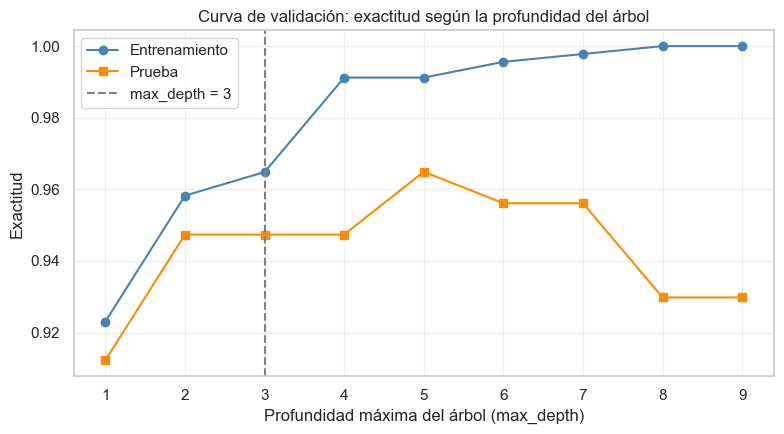

In [60]:
profundidades = range(1, 10)
train_scores, test_scores = [], []

for d in profundidades:
    arbol_d = DecisionTreeClassifier(max_depth=d, random_state=0)
    arbol_d.fit(X_train_scaled, y_train)
    train_scores.append(arbol_d.score(X_train_scaled, y_train))
    test_scores.append(arbol_d.score(X_test_scaled, y_test))

plt.figure(figsize=(8, 4.5))
plt.plot(profundidades, train_scores, "o-", label="Entrenamiento", color="steelblue")
plt.plot(profundidades, test_scores, "s-", label="Prueba", color="darkorange")
plt.axvline(3, color="gray", linestyle="--", label="max_depth = 3")
plt.xlabel("Profundidad máxima del árbol (max_depth)")
plt.ylabel("Exactitud")
plt.title("Curva de validación: exactitud según la profundidad del árbol")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La exactitud en entrenamiento sigue subiendo hasta llegar a 100 % (profundidad 8), mientras que la de prueba se estanca en torno a 94,7 % entre las profundidades 2 y 4, tiene un máximo puntual en 96,5 % (profundidad 5) y luego cae a 93,0 % cuando el árbol llega a 100 % en entrenamiento. Es decir, la brecha entre ambas curvas se ensancha con la profundidad: pasa de 1,75 puntos con `max_depth=3` a 7 puntos con el árbol sin límite. Escoger la profundidad que maximiza el resultado en prueba (5) sería hacer trampa, porque se estaría ajustando el modelo con datos de evaluación; por eso se mantiene `max_depth=3` como pide el enunciado: ofrece un buen equilibrio entre simplicidad y desempeño. **Un árbol sin límite de profundidad sobreajusta.**

## Visualización de los árboles de decisión

En los gráficos, los nodos naranjos corresponden a la clase benigna y los azules a la maligna; mientras más intenso el color, más pura es la clase del nodo.

### Árbol con restricción (max_depth=3)

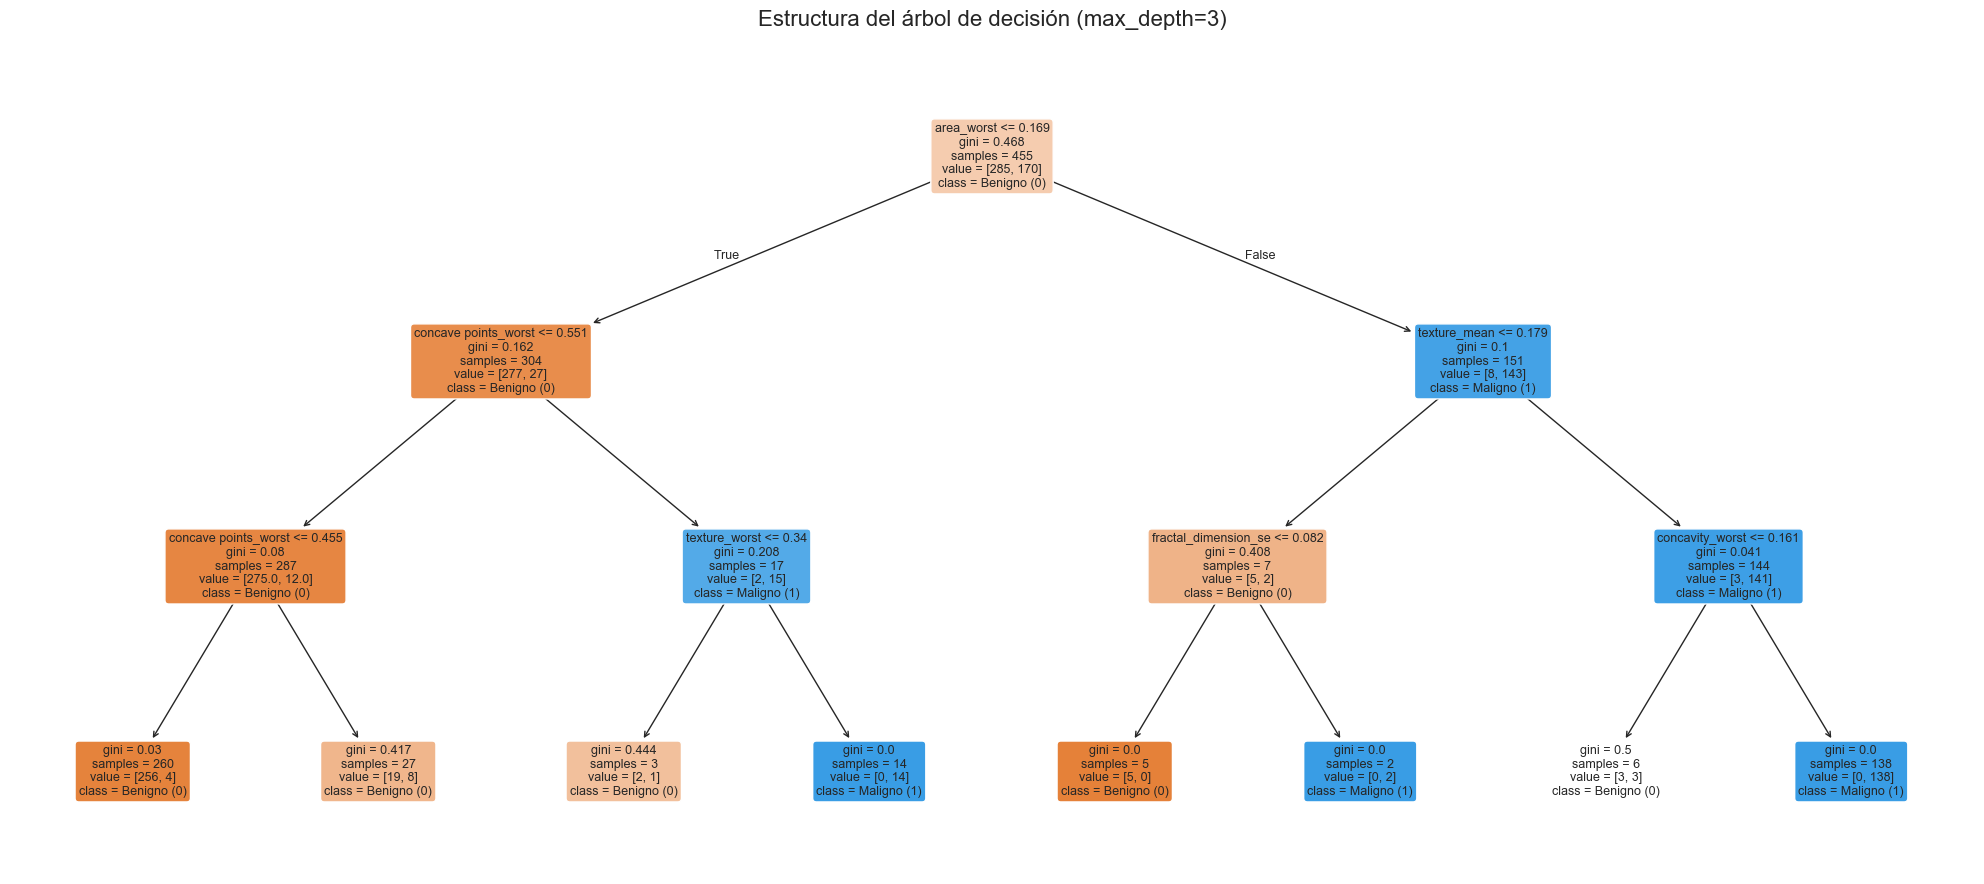

In [61]:
plt.figure(figsize=(20, 9))
plot_tree(arbol_decision, feature_names=list(X.columns), class_names=["Benigno (0)", "Maligno (1)"],
          filled=True, rounded=True, fontsize=9, precision=3)
plt.title("Estructura del árbol de decisión (max_depth=3)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

El árbol pequeño se apoya sobre todo en `area_worst` (la variable más importante, con cerca del 78 % de la importancia) y en `concave points_worst` (≈ 14 %), con pequeños aportes de la textura. Esto coincide con el análisis de correlación y se puede explicar fácilmente a un especialista.

### Árbol sin restricción

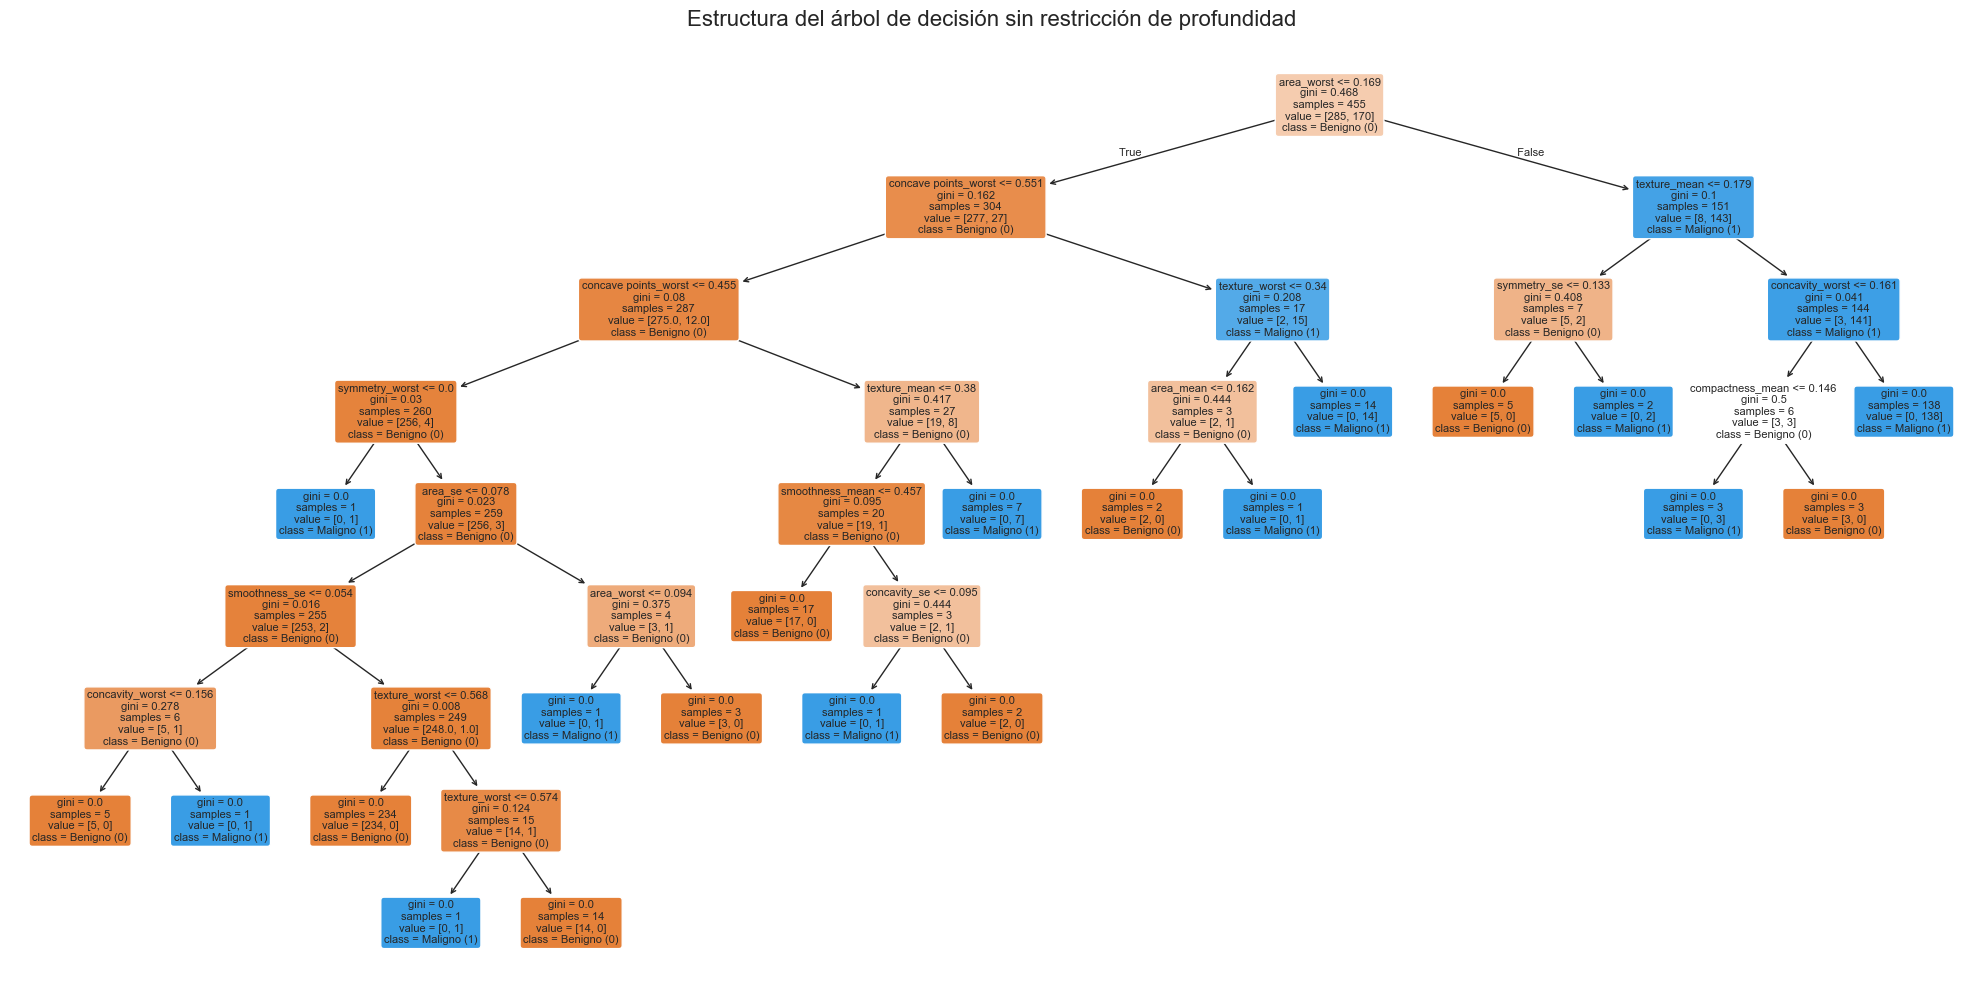

In [62]:
plt.figure(figsize=(20, 10))
plot_tree(arbol_decision_sin_rest, feature_names=list(X.columns), class_names=["Benigno (0)", "Maligno (1)"],
          filled=True, rounded=True, fontsize=8, precision=3)
plt.title("Estructura del árbol de decisión sin restricción de profundidad", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

El árbol sin restricción es bastante más grande y ramificado: crea muchos nodos para aislar unos pocos registros particulares, que es la huella visual del sobreajuste. Es más difícil de interpretar y generaliza peor.

## Interpretación de las métricas de los árboles

Se calculan las cinco métricas principales sobre la clase maligna (positiva) para cada árbol:

- **Accuracy:** proporción de predicciones correctas sobre el total.
- **Precision:** de los casos predichos como malignos, cuántos lo eran realmente (controla las falsas alarmas).
- **Recall:** de los casos malignos reales, cuántos detectó el modelo (controla los falsos negativos).
- **F1-score:** media armónica entre precision y recall.
- **ROC-AUC:** capacidad de separar las dos clases a distintos umbrales.

In [63]:
def metricas_clasificacion(nombre, modelo):
    """Métricas de un clasificador sobre el conjunto de prueba (clase positiva = maligno)."""
    pred = modelo.predict(X_test_scaled)
    prob = modelo.predict_proba(X_test_scaled)[:, 1]
    cm = confusion_matrix(y_test, pred)
    return {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, pos_label=1),
        "Recall": recall_score(y_test, pred, pos_label=1),
        "F1-score": f1_score(y_test, pred, pos_label=1),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "FN": int(cm[1, 0]),
        "FP": int(cm[0, 1]),
    }


metricas_arboles = pd.DataFrame([
    metricas_clasificacion("Árbol max_depth=3", arbol_decision),
    metricas_clasificacion("Árbol sin restricción", arbol_decision_sin_rest),
]).set_index("Modelo")
metricas_arboles.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,FN,FP
Modelo,,,,,,,
Árbol max_depth=3,0.9474,1.000,0.8571,0.9231,0.9869,6,0
Árbol sin restricción,0.9298,0.925,0.8810,0.9024,0.9196,5,3


**Árbol con `max_depth=3`:** acierta el 94,7 % de los casos. Con *precision* de 100 % no genera falsas alarmas, pero su *recall* de 85,7 % implica 6 falsos negativos: es su debilidad. El F1 (92,3 %) y el AUC (0,987) muestran que, en general, separa bien las clases.

**Árbol sin restricción:** acierta el 93,0 %. Su *precision* maligna baja a 92,5 % (genera algunas falsas alarmas) y su *recall* es de 88,1 % (5 falsos negativos). El F1 (90,2 %) y sobre todo el AUC (0,920) son claramente inferiores: un árbol totalmente profundo da probabilidades muy "duras" (0 o 1) y discrimina peor.

### ¿Mejora la exactitud al limitar la profundidad?

Se vuelven a comparar las exactitudes de entrenamiento y prueba de ambos árboles.

In [64]:
print("Con restricción (max_depth=3)")
print(f"  Entrenamiento: {acc_train_3 * 100:.2f} %")
print(f"  Prueba       : {acc_test_3 * 100:.2f} %")
print(f"  Brecha       : {(acc_train_3 - acc_test_3) * 100:.2f} puntos\n")
print("Sin restricción")
print(f"  Entrenamiento: {acc_train_full * 100:.2f} %")
print(f"  Prueba       : {acc_test_full * 100:.2f} %")
print(f"  Brecha       : {(acc_train_full - acc_test_full) * 100:.2f} puntos")

Con restricción (max_depth=3)
  Entrenamiento: 96.48 %
  Prueba       : 94.74 %
  Brecha       : 1.75 puntos

Sin restricción
  Entrenamiento: 100.00 %
  Prueba       : 92.98 %
  Brecha       : 7.02 puntos


Se observa un comportamiento distinto en cada conjunto: en **entrenamiento** la exactitud *no mejora* con la restricción, sino que baja de 100 % a 96,48 %; pero en **prueba**, que es lo que realmente importa, *sí mejora*, de 92,98 % a 94,74 %.

Esto demuestra el efecto de la regularización. Sin restricción, el árbol memoriza el entrenamiento (100 %) y generaliza peor (brecha de 7,02 puntos). Al limitar la profundidad, el modelo renuncia a la memorización perfecta para ganar capacidad de generalización, y la brecha se reduce a 1,75 puntos.

### Matrices de confusión de los árboles

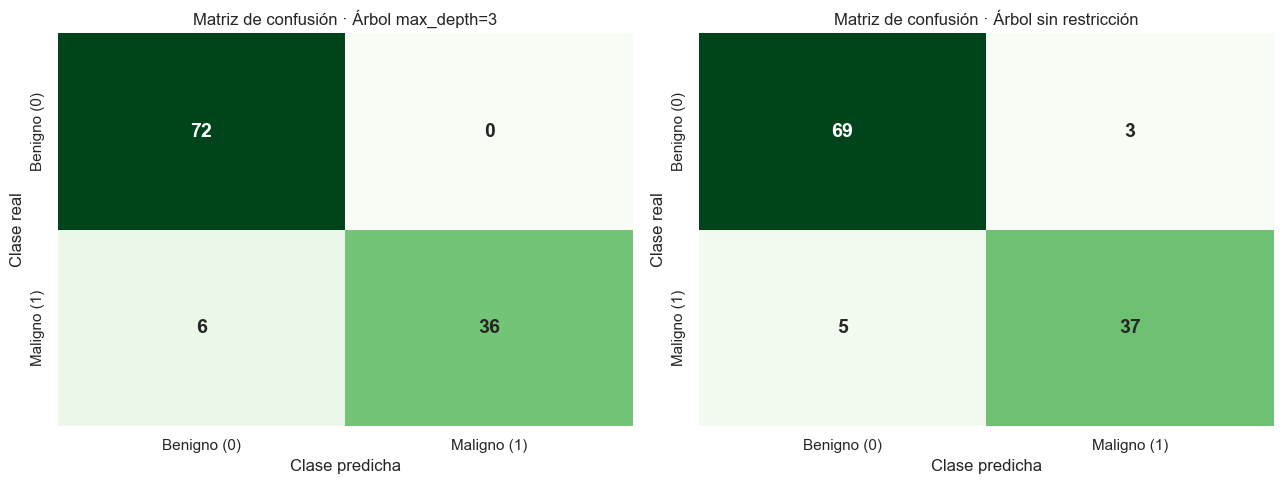

In [65]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for eje, (titulo, pred) in zip(ejes, [("Árbol max_depth=3", y_pred_arbol3),
                                       ("Árbol sin restricción", y_pred_arbol_full)]):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Greens", cbar=False,
                xticklabels=["Benigno (0)", "Maligno (1)"], yticklabels=["Benigno (0)", "Maligno (1)"],
                annot_kws={"size": 14, "weight": "bold"}, ax=eje)
    eje.set_title(f"Matriz de confusión · {titulo}")
    eje.set_xlabel("Clase predicha")
    eje.set_ylabel("Clase real")
plt.tight_layout()
plt.show()

- **Árbol con `max_depth=3`:** 72 benignos bien clasificados, 0 falsos positivos, **6 falsos negativos** (tumores malignos clasificados como benignos) y 36 malignos detectados. No se equivoca nunca al clasificar un caso benigno, pero omite 6 casos de cáncer.
- **Árbol sin restricción:** 69 benignos bien clasificados, **3 falsos positivos**, **5 falsos negativos** y 37 malignos detectados. Comete más errores en total (8 contra 6) y, además de los falsos negativos, introduce falsas alarmas.

Ambos árboles tienen más falsos negativos que la regresión logística (solo 2), lo cual es relevante en un contexto clínico.

### Conclusión sobre los árboles

El **árbol con `max_depth=3` es mejor que el árbol sin restricción**: tiene mayor exactitud en prueba (94,74 % vs. 92,98 %), mayor precision, mayor F1, mayor AUC, menos errores totales y una brecha entre entrenamiento y prueba mucho menor, es decir, **no sobreajusta**. Además, es más simple y fácil de interpretar. El único indicador en que queda levemente por debajo es el *recall* maligno (85,7 % vs. 88,1 %, una diferencia de un caso), lo que no compensa su desventaja en el resto de las métricas.

# Selección y análisis de los modelos

En esta sección se consolidan los resultados de ambos casos en tablas resumen, se elige el mejor modelo de cada uno y se justifica la decisión con las métricas.

## Tabla resumen: modelos de regresión (Caso 1)

Métricas sobre el conjunto de prueba (61 autos). Se agrega el R² promedio de la validación cruzada de 5 particiones del conjunto de entrenamiento, como medida de estabilidad.

In [66]:
tabla_resumen_regresion = tabla_regresion_final.copy()
tabla_resumen_regresion.insert(0, "Hiperparámetros", [
    {
        "SVR optimizado (GridSearchCV)": str(grid_svr.best_params_),
        "KNN optimizado (GridSearchCV)": str(grid_knn.best_params_),
        "KNN base (k=7)": "n_neighbors=7",
        "SVR base (rbf, C=1, ε=0.1)": "kernel=rbf, C=1.0, epsilon=0.1",
    }[nombre] for nombre in tabla_resumen_regresion.index
])
pd.set_option("display.max_colwidth", 80)
tabla_resumen_regresion.round(4)

,Hiperparámetros,MSE,RMSE,MAE,R² prueba,R² entrenamiento,R² validación cruzada (5 folds)
Modelo,,,,,,,
SVR optimizado (GridSearchCV),"{'C': 100, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}",1.1000,1.0488,0.6410,0.9522,0.9773,0.9316
KNN optimizado (GridSearchCV),"{'n_neighbors': 4, 'p': 2, 'weights': 'distance'}",1.2987,1.1396,0.6934,0.9436,1.0000,0.8742
KNN base (k=7),n_neighbors=7,1.6512,1.2850,0.7790,0.9283,0.8906,0.8305
"SVR base (rbf, C=1, ε=0.1)","kernel=rbf, C=1.0, epsilon=0.1",5.1198,2.2627,1.0108,0.7777,0.6565,0.6011


## Tabla resumen: modelos de clasificación (Caso 2)

Métricas sobre el conjunto de prueba (114 pacientes; clase positiva = maligno). Se agrega la exactitud promedio de la validación cruzada de 5 particiones sobre el entrenamiento y la exactitud en entrenamiento, para evaluar el sobreajuste.

In [67]:
modelos_clasificacion = {
    "Regresión Logística (base, lbfgs)": modelo_logistico,
    "Regresión Logística (GridSearchCV)": mejor_modelo_logistico,
    "Árbol de Decisión (max_depth=3)": arbol_decision,
    "Árbol de Decisión (sin restricción)": arbol_decision_sin_rest,
}

filas_clasificacion = []
for nombre, modelo in modelos_clasificacion.items():
    fila = metricas_clasificacion(nombre, modelo)
    fila["Exactitud entrenamiento"] = modelo.score(X_train_scaled, y_train)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fila["Exactitud validación cruzada (5 folds)"] = cross_val_score(
            modelo, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()
    filas_clasificacion.append(fila)

tabla_resumen_clasificacion = pd.DataFrame(filas_clasificacion).set_index("Modelo")
tabla_resumen_clasificacion.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC,FN,FP,Exactitud entrenamiento,Exactitud validación cruzada (5 folds)
Modelo,,,,,,,,,
"Regresión Logística (base, lbfgs)",0.9825,1.000,0.9524,0.9756,0.9974,2,0,0.9604,0.9538
Regresión Logística (GridSearchCV),0.9825,1.000,0.9524,0.9756,0.9974,2,0,0.9604,0.9538
Árbol de Decisión (max_depth=3),0.9474,1.000,0.8571,0.9231,0.9869,6,0,0.9648,0.9187
Árbol de Decisión (sin restricción),0.9298,0.925,0.8810,0.9024,0.9196,5,3,1.0000,0.9121


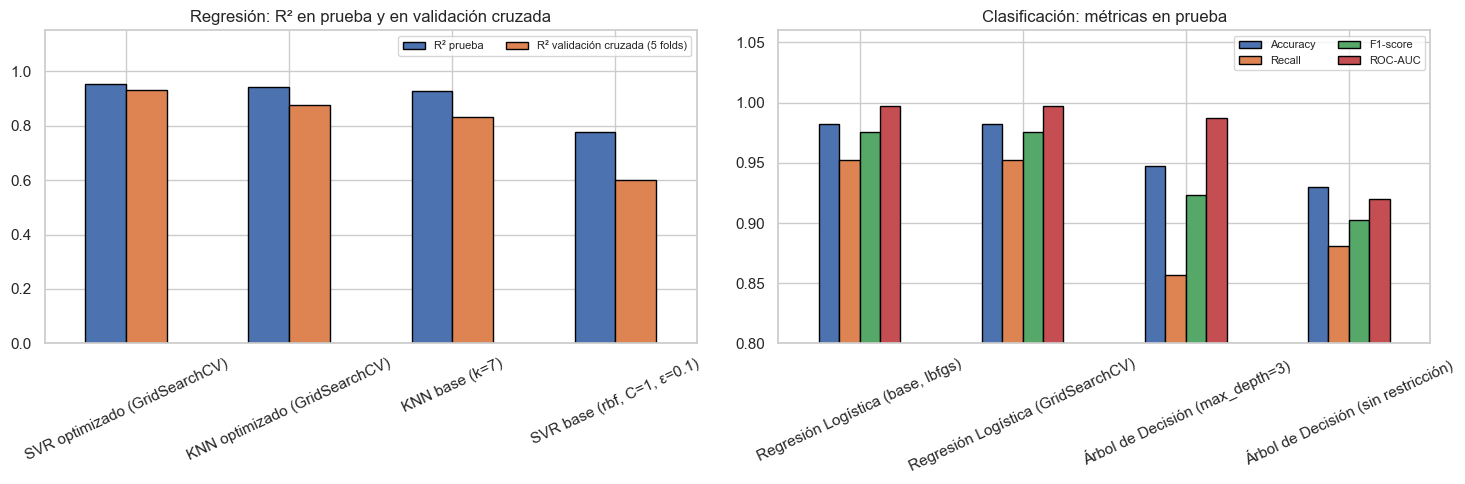

In [68]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

tabla_regresion_final[["R² prueba", "R² validación cruzada (5 folds)"]].plot(
    kind="bar", ax=ejes[0], edgecolor="black")
ejes[0].set_title("Regresión: R² en prueba y en validación cruzada")
ejes[0].set_ylim(0, 1.15)
ejes[0].tick_params(axis="x", rotation=25)

tabla_resumen_clasificacion[["Accuracy", "Recall", "F1-score", "ROC-AUC"]].plot(
    kind="bar", ax=ejes[1], edgecolor="black")
ejes[1].set_title("Clasificación: métricas en prueba")
ejes[1].set_ylim(0.8, 1.06)
ejes[1].tick_params(axis="x", rotation=25)

for eje in ejes:
    eje.set_xlabel("")
    eje.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Mejor modelo de regresión: SVR optimizado con GridSearchCV

**Elección:** `SVR(kernel='rbf', C=100, epsilon=0.1, gamma=0.01)`.

**Justificación cuantitativa:**

| Criterio | SVR optimizado | KNN optimizado | SVR base | KNN base |
|---|---|---|---|---|
| RMSE en prueba | **≈ 1,05** | ≈ 1,14 | ≈ 2,26 | ≈ 1,29 |
| R² en prueba | **≈ 0,952** | ≈ 0,944 | ≈ 0,778 | ≈ 0,928 |
| R² en validación cruzada | **≈ 0,932** | ≈ 0,874 | ≈ 0,601 | ≈ 0,831 |

- Tiene el menor error (MSE, RMSE, MAE) y el mayor R² en el conjunto de prueba.
- Es el más estable en validación cruzada, es decir, su rendimiento depende menos de qué autos caigan en la prueba.
- No sobreajusta: R² de ≈ 0,98 en entrenamiento y ≈ 0,95 en prueba. En cambio, el KNN con `weights='distance'` tiene R² de 1,0 en entrenamiento, lo que indica memorización.
- Sus errores en precios altos son menores, como se vio en el gráfico de reales contra predichos.

**Conclusión:** el modelo permite estimar el precio de venta de un auto usado explicando cerca del 95 % de la variabilidad, con un error típico de alrededor de 1 unidad de precio (el precio de venta promedio del dataset es de 4,66). Con los parámetros fijos del enunciado el ganador habría sido el KNN, lo que muestra la importancia de explorar hiperparámetros antes de comparar algoritmos.

## Mejor modelo de clasificación: Regresión Logística

**Elección:** `LogisticRegression` (la configuración base con `lbfgs` y la optimizada con `GridSearchCV` rinden exactamente igual en prueba; se recomienda la regresión logística con las variables escaladas con `MinMaxScaler`).

**Justificación cuantitativa:**

| Criterio | Regresión Logística | Árbol max_depth=3 | Árbol sin restricción |
|---|---|---|---|
| Accuracy en prueba | **98,25 %** | 94,74 % | 92,98 % |
| Recall maligno | **95,24 %** | 85,71 % | 88,10 % |
| Precision maligno | **100 %** | 100 % | 92,50 % |
| F1 maligno | **97,56 %** | 92,31 % | 90,24 % |
| ROC-AUC | **0,997** | 0,987 | 0,920 |
| Falsos negativos | **2** | 6 | 5 |

- Es el mejor en todas las métricas y comete la menor cantidad de falsos negativos (2), que son los errores más graves en un diagnóstico de cáncer (un tumor maligno que no se detecta).
- No sobreajusta: la exactitud en prueba (98,25 %) es similar o superior a la de entrenamiento (96,04 %), a diferencia del árbol sin restricción (100 % vs. 92,98 %).
- Su exactitud en validación cruzada (≈ 95,4 %) es la más alta de los cuatro modelos (los árboles obtienen ≈ 91,9 % y ≈ 91,2 %), lo que confirma que el resultado no depende de una única partición.
- Entre los árboles gana el de `max_depth=3`, porque el árbol sin restricción sobreajusta; pero ninguno alcanza el desempeño de la regresión logística.

**Conclusión:** la regresión logística es el modelo recomendado para apoyar el diagnóstico. Si se necesitara un modelo fácilmente explicable a un especialista, el árbol con `max_depth=3` es la alternativa, a costa de más falsos negativos.

## Conclusiones generales

1. **Regresión (precio de venta):** el SVR optimizado es el mejor modelo (R² ≈ 0,95; RMSE ≈ 1,05). El KNN fue mejor solo con los parámetros base del enunciado, porque el SVR con `C=1` estaba subajustado. Explorar hiperparámetros cambió el ganador.
2. **Clasificación (cáncer de mama):** la regresión logística es el mejor modelo (exactitud de 98,25 %, AUC de 0,997 y solo 2 falsos negativos). El árbol de decisión con `max_depth=3` supera al árbol sin restricción, que sobreajusta (100 % en entrenamiento contra 92,98 % en prueba).
3. **Preprocesamiento:** el escalamiento (StandardScaler y MinMaxScaler, siempre ajustados solo con el entrenamiento), el tratamiento de la multicolinealidad con VIF y la corrección del encabezado del dataset de autos fueron determinantes para obtener resultados confiables.
4. **Desbalance de clases:** con una razón de 1,68 : 1 el desbalance es leve; se comprobó experimentalmente que `class_weight='balanced'` no cambia el resultado, por lo que bastó con la partición estratificada y el análisis de *recall*, *F1* y AUC.
5. **Limitaciones:** ambos datasets son pequeños (301 y 569 registros) y las métricas de prueba se calculan con pocos casos (61 y 114), por lo que pequeñas diferencias entre modelos deben interpretarse con cautela. Una mejora futura sería usar validación cruzada repetida y más datos.

## Fuentes y referencias

- Documentación de scikit-learn: SVR, KNeighborsRegressor, LogisticRegression, DecisionTreeClassifier, GridSearchCV, StandardScaler, MinMaxScaler y métricas. https://scikit-learn.org/stable/
- Documentación de pandas (`read_csv`, `get_dummies`). https://pandas.pydata.org/docs/
- Documentación de statsmodels (`variance_inflation_factor`). https://www.statsmodels.org/stable/
- Dataset de autos usados *Vehicle dataset from CarDekho*, Kaggle. https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho
- Dataset *Breast Cancer Wisconsin (Diagnostic)*, UCI Machine Learning Repository / Kaggle. https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
- Özmen, A. *Understanding Multicollinearity: Its Impact on Data Analysis and Machine Learning.* https://medium.com/@azizozmen/understanding-multicollinearity-its-impact-on-data-analysis-and-machine-learning-94da6620569e
- Coşgun, H. *Which Data Scaling Technique Should I Use?* https://medium.com/@hhuseyincosgun/which-data-scaling-technique-should-i-use-a1615292061e
- Material de clases y enunciado del encargo EP3 TLY1101.
- Herramienta de IA utilizada: OpenCode (asistente de programación).